# Адаптивная ML-модель для ребалансировки инвестиционного портфеля

В ноутбуке реализован полный исследовательский pipeline: загрузка исторических рыночных данных, подготовка признаков, построение модели прогнозирования доходности, оптимизация весов портфеля, walk-forward бэктестирование и визуальная оценка результатов.

Код разделён на логические блоки. Все пояснения вынесены в Markdown-ячейки, а кодовые ячейки не содержат комментариев.

## 1. Установка библиотек

Для работы используются библиотеки `pandas`, `numpy`, `yfinance`, `scikit-learn`, `scipy` и `matplotlib`. Исторические данные загружаются через Yahoo Finance, поскольку этот источник удобен для автоматической загрузки большого набора тикеров в Jupyter Notebook.

In [1]:
%pip install -q yfinance scikit-learn scipy matplotlib tqdm


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Импорт библиотек и базовые настройки

В этом блоке подключаются библиотеки для работы с данными, машинного обучения, численной оптимизации и визуализации. Также отключаются предупреждения, чтобы вывод ноутбука был чище.

In [2]:
import time
import warnings
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

from IPython.display import display
from scipy.optimize import minimize
from tqdm.auto import tqdm
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

## 3. Формирование инвестиционной вселенной

Инвестиционная вселенная включает ETF, фондовые индексы, крупнейшие технологические компании, финансовый сектор, потребительский сектор, здравоохранение, энергетику и промышленность. Исходные тикеры записаны в формате Stooq, а далее автоматически преобразуются в формат Yahoo Finance.

In [3]:
symbols_stooq = [
    "spy.us", "qqq.us", "aapl.us", "msft.us", "amzn.us", "goog.us", "nvda.us", "meta.us",
    "^spx", "^vix", "tlt.us", "gld.us", "jpm.us", "bac.us", "wfc.us", "c.us", "gs.us",
    "ms.us", "blk.us", "tsla.us", "adbe.us", "crm.us", "intc.us", "amd.us", "orcl.us",
    "csco.us", "avgo.us", "cost.us", "wmt.us", "hd.us", "pg.us", "ko.us", "pep.us",
    "mcd.us", "nke.us", "jnj.us", "pfe.us", "mrk.us", "abbv.us", "tmo.us", "unh.us",
    "xom.us", "cvx.us", "slb.us", "oxy.us", "cat.us", "ba.us", "hon.us", "ups.us", "rtx.us"
]

## 4. Функции загрузки и нормализации рыночных данных

На этом этапе тикеры переводятся в формат Yahoo Finance, данные загружаются единым запросом, а затем приводятся к длинному формату. Длинный формат удобен для построения признаков и обучения модели, так как каждая строка соответствует одной дате и одному инструменту.

In [4]:
def stooq_to_yahoo(sym: str) -> str:
    sym = sym.lower()
    mapping = {
        "^spx": "^GSPC",
        "^vix": "^VIX"
    }
    if sym in mapping:
        return mapping[sym]
    if sym.endswith(".us"):
        return sym.replace(".us", "").upper()
    return sym.upper()


def extract_ticker_frame(raw_data: pd.DataFrame, yahoo_ticker: str) -> pd.DataFrame:
    if raw_data.empty:
        return pd.DataFrame()
    if isinstance(raw_data.columns, pd.MultiIndex):
        level_0 = raw_data.columns.get_level_values(0)
        level_1 = raw_data.columns.get_level_values(1)
        if yahoo_ticker in level_0:
            return raw_data[yahoo_ticker].copy()
        if yahoo_ticker in level_1:
            return raw_data.xs(yahoo_ticker, axis=1, level=1).copy()
        return pd.DataFrame()
    return raw_data.copy()


def normalize_price_frame(price_frame: pd.DataFrame, ticker: str) -> pd.DataFrame:
    df = price_frame.copy().reset_index()
    column_mapping = {}
    for col in df.columns:
        key = str(col).strip().lower()
        if key in ["date", "datetime"]:
            column_mapping[col] = "dt"
        elif key == "open":
            column_mapping[col] = "open"
        elif key == "high":
            column_mapping[col] = "high"
        elif key == "low":
            column_mapping[col] = "low"
        elif key == "close":
            column_mapping[col] = "close"
        elif key == "adj close":
            column_mapping[col] = "adj_close"
        elif key == "volume":
            column_mapping[col] = "volume"
    df = df.rename(columns=column_mapping)
    df["dt"] = pd.to_datetime(df["dt"], errors="coerce")
    df["ticker"] = ticker
    keep = [c for c in ["dt", "ticker", "open", "high", "low", "close", "adj_close", "volume"] if c in df.columns]
    df = df[keep].dropna(subset=["dt", "close"])
    return df.sort_values(["ticker", "dt"]).reset_index(drop=True)


def load_market_data(symbols: list, period: str = "max", interval: str = "1d"):
    symbols_yahoo = [stooq_to_yahoo(s) for s in symbols]
    ticker_map = dict(zip(symbols_yahoo, [s.upper() for s in symbols]))
    raw_data = yf.download(
        tickers=symbols_yahoo,
        period=period,
        interval=interval,
        auto_adjust=False,
        group_by="ticker",
        threads=True,
        progress=True
    )
    frames = []
    failed = []
    for yahoo_ticker in tqdm(symbols_yahoo, desc="Normalizing downloaded tickers", leave=False):
        try:
            price_frame = extract_ticker_frame(raw_data, yahoo_ticker)
            if price_frame.empty:
                failed.append((yahoo_ticker, "no data returned"))
                continue
            ticker = ticker_map.get(yahoo_ticker, yahoo_ticker)
            normalized = normalize_price_frame(price_frame, ticker)
            if normalized.empty:
                failed.append((yahoo_ticker, "empty after normalization"))
                continue
            frames.append(normalized)
        except Exception as exc:
            failed.append((yahoo_ticker, repr(exc)))
    if not frames:
        raise RuntimeError(f"No data loaded: {failed}")
    df_all = pd.concat(frames, ignore_index=True)
    df_all = df_all.drop_duplicates(subset=["dt", "ticker"]).sort_values(["dt", "ticker"]).reset_index(drop=True)
    df_close = df_all.pivot(index="dt", columns="ticker", values="close").sort_index()
    return df_all, df_close, failed

## 5. Загрузка данных и первичная проверка

После загрузки формируются две таблицы: `df_all` в длинном формате и `df_close` в широком формате. Первая таблица используется для построения ML-признаков, вторая удобна для анализа динамики цен и ковариаций.

In [5]:
df_all, df_close, failed_downloads = load_market_data(symbols_stooq)

print("df_all:", df_all.shape)
print("df_close:", df_close.shape)

if failed_downloads:
    print("FAILED DOWNLOADS")
    for ticker, reason in failed_downloads:
        print(ticker, reason)

display(df_all.head())
display(df_close.head())

[*********************100%***********************]  50 of 50 completed


Normalizing downloaded tickers:   0%|          | 0/50 [00:00<?, ?it/s]

df_all: (549456, 8)
df_close: (24710, 50)


Price,dt,ticker,open,high,low,close,adj_close,volume
0,1927-12-30,^SPX,17.660000,17.660000,17.660000,17.660000,17.660000,0.0
1,1928-01-03,^SPX,17.760000,17.760000,17.760000,17.760000,17.760000,0.0
2,1928-01-04,^SPX,17.719999,17.719999,17.719999,17.719999,17.719999,0.0
3,1928-01-05,^SPX,17.549999,17.549999,17.549999,17.549999,17.549999,0.0
4,1928-01-06,^SPX,17.660000,17.660000,17.660000,17.660000,17.660000,0.0


ticker,AAPL.US,ABBV.US,ADBE.US,AMD.US,AMZN.US,AVGO.US,BA.US,BAC.US,BLK.US,C.US,...,TLT.US,TMO.US,TSLA.US,UNH.US,UPS.US,WFC.US,WMT.US,XOM.US,^SPX,^VIX
dt,,,,,,,,,,,,,,,,,,,,,
1927-12-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.660000,NaN
1928-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.760000,NaN
1928-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.719999,NaN
1928-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.549999,NaN
1928-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.660000,NaN


## 6. Ограничение периода исследования

Для бэктеста используется период с 2020 года. Это позволяет сфокусироваться на современной рыночной динамике, включая кризисные и посткризисные периоды, а также снижает вычислительную нагрузку.

In [6]:
START_DATE = "2020-01-01"

df_all = df_all[df_all["dt"] >= pd.to_datetime(START_DATE)].copy().reset_index(drop=True)
df_close = df_all.pivot(index="dt", columns="ticker", values="close").sort_index()

print("df_all:", df_all.shape)
print("df_close:", df_close.shape)

display(df_all.head())

df_all: (80050, 8)
df_close: (1601, 50)


Price,dt,ticker,open,high,low,close,adj_close,volume
0,2020-01-02,AAPL.US,74.059998,75.150002,73.797501,75.087502,72.333885,135480400.0
1,2020-01-02,ABBV.US,89.080002,89.570000,88.510002,89.550003,68.696251,5639200.0
2,2020-01-02,ADBE.US,330.000000,334.480011,329.170013,334.429993,334.429993,1990100.0
3,2020-01-02,AMD.US,46.860001,49.250000,46.630001,49.099998,49.099998,80331100.0
4,2020-01-02,AMZN.US,93.750000,94.900497,93.207497,94.900497,94.900497,80580000.0


## 7. Подготовка признаков для модели

Модель использует технические признаки, рассчитанные на основе цен: краткосрочные и среднесрочные доходности, историческую волатильность, отношение цены к скользящим средним и внутридневной диапазон. Целевая переменная — будущая доходность инструмента на выбранном горизонте.

In [7]:
def prepare_features(df_all: pd.DataFrame, horizon: int = 1, use_volume_features: bool = False):
    df = df_all.copy()
    df["dt"] = pd.to_datetime(df["dt"], errors="coerce")
    df["ticker"] = df["ticker"].astype(str).str.upper()
    df = df.sort_values(["ticker", "dt"]).reset_index(drop=True)

    num_cols = [c for c in ["open", "high", "low", "close", "volume"] if c in df.columns]
    for col in num_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

    df = df.dropna(subset=["dt", "ticker", "close"]).copy()
    df = df[df["close"] > 0].copy()

    eps = 1e-12
    grp = df.groupby("ticker")

    df["ret_1"] = grp["close"].pct_change(1)
    df["ret_3"] = grp["close"].pct_change(3)
    df["ret_5"] = grp["close"].pct_change(5)
    df["ret_10"] = grp["close"].pct_change(10)
    df["ret_20"] = grp["close"].pct_change(20)
    df["ret_60"] = grp["close"].pct_change(60)

    df["vol_5"] = grp["ret_1"].rolling(5).std().reset_index(level=0, drop=True)
    df["vol_10"] = grp["ret_1"].rolling(10).std().reset_index(level=0, drop=True)
    df["vol_20"] = grp["ret_1"].rolling(20).std().reset_index(level=0, drop=True)
    df["vol_60"] = grp["ret_1"].rolling(60).std().reset_index(level=0, drop=True)

    df["ma_5"] = grp["close"].rolling(5).mean().reset_index(level=0, drop=True)
    df["ma_10"] = grp["close"].rolling(10).mean().reset_index(level=0, drop=True)
    df["ma_20"] = grp["close"].rolling(20).mean().reset_index(level=0, drop=True)
    df["ma_60"] = grp["close"].rolling(60).mean().reset_index(level=0, drop=True)

    df["std_20"] = grp["close"].rolling(20).std().reset_index(level=0, drop=True)
    df["price_to_ma5"] = df["close"] / (df["ma_5"] + eps) - 1.0
    df["price_to_ma10"] = df["close"] / (df["ma_10"] + eps) - 1.0
    df["price_to_ma20"] = df["close"] / (df["ma_20"] + eps) - 1.0
    df["price_to_ma60"] = df["close"] / (df["ma_60"] + eps) - 1.0
    df["zscore_20"] = (df["close"] - df["ma_20"]) / (df["std_20"] + eps)
    df["trend_20_60"] = df["ma_20"] / (df["ma_60"] + eps) - 1.0

    if all(c in df.columns for c in ["high", "low", "close", "open"]):
        df["intraday_range"] = (df["high"] - df["low"]) / (df["close"] + eps)
        df["close_open"] = (df["close"] - df["open"]) / (df["open"] + eps)
        prev_close = grp["close"].shift(1)
        tr1 = df["high"] - df["low"]
        tr2 = (df["high"] - prev_close).abs()
        tr3 = (df["low"] - prev_close).abs()
        df["true_range"] = np.maximum.reduce([tr1.fillna(0), tr2.fillna(0), tr3.fillna(0)])
        df["atr_14"] = grp["true_range"].rolling(14).mean().reset_index(level=0, drop=True) / (df["close"] + eps)
    else:
        df["intraday_range"] = np.nan
        df["close_open"] = np.nan
        df["atr_14"] = np.nan

    delta = grp["close"].diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)
    avg_gain = gain.groupby(df["ticker"]).rolling(14).mean().reset_index(level=0, drop=True)
    avg_loss = loss.groupby(df["ticker"]).rolling(14).mean().reset_index(level=0, drop=True)
    rs = avg_gain / (avg_loss + eps)
    df["rsi_14"] = 100 - (100 / (1 + rs))
    df["rsi_14"] = (df["rsi_14"] / 100.0) - 0.5

    rolling_max_20 = grp["close"].rolling(20).max().reset_index(level=0, drop=True)
    rolling_min_20 = grp["close"].rolling(20).min().reset_index(level=0, drop=True)
    rolling_max_60 = grp["close"].rolling(60).max().reset_index(level=0, drop=True)
    rolling_min_60 = grp["close"].rolling(60).min().reset_index(level=0, drop=True)
    df["breakout_20"] = df["close"] / (rolling_max_20 + eps) - 1.0
    df["rebound_20"] = df["close"] / (rolling_min_20 + eps) - 1.0
    df["breakout_60"] = df["close"] / (rolling_max_60 + eps) - 1.0
    df["rebound_60"] = df["close"] / (rolling_min_60 + eps) - 1.0

    df["mom_vol_20"] = df["ret_20"] / (df["vol_20"] * np.sqrt(20) + eps)
    df["mom_vol_60"] = df["ret_60"] / (df["vol_60"] * np.sqrt(60) + eps)

    benchmark_candidates = ["SPY.US", "^SPX", "QQQ.US"]
    benchmark_df = None
    for bench in benchmark_candidates:
        bench_df = df[df["ticker"] == bench][["dt", "close"]].drop_duplicates("dt").sort_values("dt")
        if len(bench_df) > 100:
            benchmark_df = bench_df.copy()
            benchmark_df["mkt_ret_1"] = benchmark_df["close"].pct_change(1)
            benchmark_df["mkt_ret_5"] = benchmark_df["close"].pct_change(5)
            benchmark_df["mkt_ret_20"] = benchmark_df["close"].pct_change(20)
            benchmark_df["mkt_ret_60"] = benchmark_df["close"].pct_change(60)
            break

    if benchmark_df is not None:
        df = df.merge(
            benchmark_df[["dt", "mkt_ret_1", "mkt_ret_5", "mkt_ret_20", "mkt_ret_60"]],
            on="dt",
            how="left"
        )
        df["rel_ret_1"] = df["ret_1"] - df["mkt_ret_1"]
        df["rel_ret_5"] = df["ret_5"] - df["mkt_ret_5"]
        df["rel_ret_20"] = df["ret_20"] - df["mkt_ret_20"]
        df["rel_ret_60"] = df["ret_60"] - df["mkt_ret_60"]

        cov_20 = (
            df.groupby("ticker")
            .apply(lambda x: x["ret_1"].rolling(20).cov(x["mkt_ret_1"]))
            .reset_index(level=0, drop=True)
        )
        mkt_var_20 = benchmark_df.set_index("dt")["mkt_ret_1"].rolling(20).var()
        df["beta_20"] = cov_20.values / (df["dt"].map(mkt_var_20).values + eps)
    else:
        df["rel_ret_1"] = df["ret_1"]
        df["rel_ret_5"] = df["ret_5"]
        df["rel_ret_20"] = df["ret_20"]
        df["rel_ret_60"] = df["ret_60"]
        df["beta_20"] = np.nan

    base_features = [
        "ret_1", "ret_3", "ret_5", "ret_10", "ret_20", "ret_60",
        "rel_ret_1", "rel_ret_5", "rel_ret_20", "rel_ret_60",
        "vol_5", "vol_10", "vol_20", "vol_60",
        "price_to_ma5", "price_to_ma10", "price_to_ma20", "price_to_ma60",
        "zscore_20", "trend_20_60", "intraday_range", "close_open", "atr_14",
        "rsi_14", "breakout_20", "rebound_20", "breakout_60", "rebound_60",
        "mom_vol_20", "mom_vol_60", "beta_20"
    ]

    if use_volume_features and "volume" in df.columns:
        df["vol_chg_5"] = grp["volume"].pct_change(5)
        df["vol_chg_20"] = grp["volume"].pct_change(20)
        df["volume_ma_5"] = grp["volume"].rolling(5).mean().reset_index(level=0, drop=True)
        df["volume_ma_20"] = grp["volume"].rolling(20).mean().reset_index(level=0, drop=True)
        df["volume_ratio_5"] = df["volume"] / (df["volume_ma_5"] + eps) - 1.0
        df["volume_ratio_20"] = df["volume"] / (df["volume_ma_20"] + eps) - 1.0
        base_features += ["vol_chg_5", "vol_chg_20", "volume_ratio_5", "volume_ratio_20"]

    feature_cols = list(base_features)

    for col in list(base_features):
        cs_col = f"cs_{col}"
        df[cs_col] = (
            df.groupby("dt")[col]
            .rank(pct=True, method="average")
            .sub(0.5)
        )
        feature_cols.append(cs_col)

    df["target"] = grp["close"].shift(-horizon) / df["close"] - 1.0

    feature_set = feature_cols + ["target"]
    df[feature_set] = df[feature_set].replace([np.inf, -np.inf], np.nan)

    for col in feature_cols:
        q01 = df[col].quantile(0.01)
        q99 = df[col].quantile(0.99)
        if pd.notna(q01) and pd.notna(q99):
            df[col] = df[col].clip(q01, q99)

    t01 = df["target"].quantile(0.01)
    t99 = df["target"].quantile(0.99)
    if pd.notna(t01) and pd.notna(t99):
        df["target"] = df["target"].clip(t01, t99)

    df = df.dropna(subset=feature_cols + ["target"]).reset_index(drop=True)
    return df, feature_cols

## 8. Метрики качества ML-модели

Качество прогнозов оценивается как с помощью классических регрессионных метрик, так и с помощью финансово-интерпретируемых показателей. Directional Accuracy показывает, насколько часто модель правильно предсказывает направление доходности, а Information Coefficient оценивает корреляцию прогнозов и фактических доходностей в разрезе дат.

In [8]:
def compute_ml_metrics(preds_df: pd.DataFrame) -> dict:
    metrics = {}
    if preds_df is None or preds_df.empty:
        return metrics
    sample = preds_df.dropna(subset=["target", "prediction"]).copy()
    if len(sample) < 2:
        return metrics
    y_true = sample["target"].values
    y_pred = sample["prediction"].values
    metrics["MSE"] = mean_squared_error(y_true, y_pred)
    metrics["RMSE"] = np.sqrt(metrics["MSE"])
    metrics["MAE"] = mean_absolute_error(y_true, y_pred)
    metrics["R2"] = r2_score(y_true, y_pred)
    metrics["Directional Accuracy"] = np.mean(np.sign(y_true) == np.sign(y_pred))
    metrics["Prediction Corr"] = sample[["target", "prediction"]].corr().iloc[0, 1]
    daily_ic = sample.groupby("dt")[["prediction", "target"]].apply(lambda x: x["prediction"].corr(x["target"])).reset_index(name="IC")
    metrics["Mean IC"] = daily_ic["IC"].mean()
    metrics["Median IC"] = daily_ic["IC"].median()
    return metrics

## 9. Оптимизация весов портфеля

На основе прогнозов модели формируется портфель. В оптимизации используются только инструменты с положительным прогнозом ожидаемой доходности. Целевая функция может максимизировать аналог коэффициента Шарпа, максимизировать ожидаемую доходность или минимизировать риск. Для устойчивости применяется ограничение на максимальный вес одного актива.

In [9]:
def optimize_weights_from_predictions(
    day_data: pd.DataFrame,
    objective: str = "max_sharpe",
    max_weight: float = 0.30,
    rf_daily: float = 0.0,
    top_n: int = 12,
    min_prediction: float = 0.0
):
    x = day_data.copy()
    x = x.dropna(subset=["prediction", "vol_20"]).copy()
    x["risk_proxy"] = x["vol_20"].clip(lower=x["vol_20"].quantile(0.15))
    x = x[x["prediction"] > min_prediction].copy()
    if x.empty:
        return pd.DataFrame(columns=["ticker", "weight", "prediction"])

    x["score"] = x["prediction"] / (x["risk_proxy"] + 1e-9)
    x = x.sort_values(["score", "prediction"], ascending=False).head(top_n).copy()
    if x.empty:
        return pd.DataFrame(columns=["ticker", "weight", "prediction"])

    n = len(x)
    upper_bound = min(1.0, max(max_weight, 1.0 / n))
    mu = x["prediction"].values
    sigma = x["risk_proxy"].values
    sigma = np.where((sigma <= 0) | np.isnan(sigma), np.nanmedian(sigma), sigma)
    sigma = np.where(np.isnan(sigma), 0.02, sigma)
    cov = np.diag(np.square(sigma))

    def port_return(w):
        return float(np.dot(w, mu))

    def port_vol(w):
        return float(np.sqrt(w.T @ cov @ w))

    def neg_sharpe(w):
        vol = port_vol(w)
        if vol == 0:
            return 1e6
        return -((port_return(w) - rf_daily) / vol)

    def neg_return(w):
        return -port_return(w)

    def min_vol(w):
        return port_vol(w)

    objective_map = {
        "max_sharpe": neg_sharpe,
        "max_return": neg_return,
        "min_vol": min_vol
    }
    if objective not in objective_map:
        raise ValueError("objective must be max_sharpe, max_return or min_vol")

    score_weights = np.maximum(x["score"].values, 0)
    if score_weights.sum() == 0:
        score_weights = np.ones(n)
    x0 = score_weights / score_weights.sum()
    bounds = [(0.0, upper_bound) for _ in range(n)]
    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    result = minimize(objective_map[objective], x0=x0, method="SLSQP", bounds=bounds, constraints=constraints)

    if result.success:
        weights = result.x.copy()
    else:
        weights = x0.copy()

    weights = np.clip(weights, 0, upper_bound)
    if weights.sum() == 0:
        weights = x0.copy()
    weights = weights / weights.sum()

    out = pd.DataFrame({
        "ticker": x["ticker"].values,
        "weight": weights,
        "prediction": x["prediction"].values,
        "score": x["score"].values
    })
    return out.sort_values("weight", ascending=False).reset_index(drop=True)

## 10. Walk-forward бэктестирование

Бэктест построен по схеме walk-forward. На каждом шаге модель обучается только на историческом окне данных, затем делает прогноз на текущую дату. Портфель оптимизируется по прогнозам, после чего рассчитывается фактическая доходность с учётом транзакционных издержек и оборота портфеля.

In [10]:

def build_hybrid_models(random_state: int = 42):
    return {
        "linear": Ridge(alpha=2.0),
        "rf_resid": RandomForestRegressor(
            n_estimators=350,
            max_depth=8,
            min_samples_leaf=10,
            max_features="sqrt",
            bootstrap=True,
            random_state=random_state,
            n_jobs=-1
        ),
        "et_resid": ExtraTreesRegressor(
            n_estimators=450,
            max_depth=10,
            min_samples_leaf=8,
            max_features="sqrt",
            random_state=random_state + 1,
            n_jobs=-1
        ),
        "hgb_resid": HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.035,
            max_depth=5,
            max_iter=300,
            min_samples_leaf=20,
            l2_regularization=1.0,
            random_state=random_state + 2
        )
    }


def fit_hybrid_and_predict(
    x_train: pd.DataFrame,
    y_train: pd.Series,
    x_test: pd.DataFrame,
    random_state: int = 42
):
    models = build_hybrid_models(random_state=random_state)

    train_len = len(x_train)
    recency_weights = np.linspace(0.5, 1.0, train_len)
    y_low, y_high = np.nanquantile(y_train, [0.01, 0.99])
    y_train_clip = y_train.clip(y_low, y_high)

    linear_model = models["linear"]
    linear_model.fit(x_train, y_train_clip, sample_weight=recency_weights)
    linear_train_pred = linear_model.predict(x_train)
    linear_test_pred = linear_model.predict(x_test)

    residual_target = y_train_clip - linear_train_pred
    residual_models = {k: v for k, v in models.items() if k != "linear"}

    residual_pred_parts = []
    fi_parts = []

    for name, model in residual_models.items():
        try:
            model.fit(x_train, residual_target, sample_weight=recency_weights)
        except TypeError:
            model.fit(x_train, residual_target)
        residual_pred_parts.append(model.predict(x_test))

        if hasattr(model, "feature_importances_"):
            fi_parts.append(pd.Series(model.feature_importances_, index=x_train.columns, name=name))

    if residual_pred_parts:
        residual_pred_mat = np.column_stack(residual_pred_parts)
        residual_weights = np.array([0.40, 0.35, 0.25])[: residual_pred_mat.shape[1]]
        residual_weights = residual_weights / residual_weights.sum()
        residual_pred = residual_pred_mat @ residual_weights
    else:
        residual_pred = np.zeros(len(x_test), dtype=float)

    final_pred = linear_test_pred + residual_pred
    final_pred = np.clip(final_pred, y_low, y_high)

    linear_importance = pd.Series(np.abs(np.ravel(linear_model.coef_)), index=x_train.columns, name="linear")
    fi_parts = [linear_importance] + fi_parts
    fi_df = pd.concat(fi_parts, axis=1).mean(axis=1).reset_index()
    fi_df.columns = ["feature", "importance"]

    fitted = {"linear": linear_model}
    fitted.update(residual_models)
    return fitted, final_pred, fi_df


def backtest_ml_optimized_portfolio(
    data: pd.DataFrame,
    feature_cols: list,
    model,
    train_window: int = 252,
    retrain_freq: int = 21,
    rebalance_freq: int = None,
    objective: str = "max_sharpe",
    max_weight: float = 0.30,
    transaction_cost: float = 0.001,
    horizon: int = 1,
    verbose_every: int = 50,
    show_progress: bool = True
):
    df = data.copy().sort_values(["dt", "ticker"]).reset_index(drop=True)
    df["dt"] = pd.to_datetime(df["dt"])
    unique_dates = sorted(df["dt"].unique())
    if rebalance_freq is None:
        rebalance_freq = max(1, int(horizon))

    results = []
    predictions_store = []
    feature_importances_log = []
    current_weights = {}
    trained_models = None

    close_panel = (
        df.pivot_table(index="dt", columns="ticker", values="close", aggfunc="last")
        .sort_index()
    )

    rebalance_points = list(range(train_window, len(unique_dates) - rebalance_freq, rebalance_freq))
    step_iterator = tqdm(rebalance_points, desc="Walk-forward backtest", disable=not show_progress)

    for step_idx, i in enumerate(step_iterator, start=1):
        current_date = pd.Timestamp(unique_dates[i])
        next_date = pd.Timestamp(unique_dates[i + rebalance_freq])
        need_verbose = step_idx == 1 or step_idx % verbose_every == 0

        retrain_step = max(1, retrain_freq // rebalance_freq) if retrain_freq >= rebalance_freq else 1
        if ((step_idx - 1) % retrain_step == 0) or trained_models is None:
            train_start = pd.Timestamp(unique_dates[i - train_window])
            train_end = current_date
            train_mask = (df["dt"] >= train_start) & (df["dt"] < train_end)
            train_data = df.loc[train_mask].copy().sort_values(["dt", "ticker"])

            x_train = train_data[feature_cols].replace([np.inf, -np.inf], np.nan)
            y_train = train_data["target"].copy()

            valid_mask = x_train.notna().all(axis=1) & y_train.notna()
            x_train = x_train.loc[valid_mask].clip(-1e6, 1e6)
            y_train = y_train.loc[valid_mask]

            if len(x_train) < 200:
                continue

            trained_models, _, fi = fit_hybrid_and_predict(
                x_train=x_train,
                y_train=y_train,
                x_test=x_train.iloc[:1],
                random_state=42 + step_idx
            )
            if not fi.empty:
                fi["retrain_dt"] = current_date
                feature_importances_log.append(fi)

        day_data = df[df["dt"] == current_date].copy()
        if day_data.empty or trained_models is None:
            continue

        x_day = day_data[feature_cols].replace([np.inf, -np.inf], np.nan).clip(-1e6, 1e6)
        valid_day_mask = x_day.notna().all(axis=1)
        x_day = x_day.loc[valid_day_mask]
        day_data = day_data.loc[valid_day_mask].copy()

        if day_data.empty:
            continue

        linear_pred = trained_models["linear"].predict(x_day)
        residual_parts = []
        for name in ["rf_resid", "et_resid", "hgb_resid"]:
            if name in trained_models:
                residual_parts.append(trained_models[name].predict(x_day))
        if residual_parts:
            residual_pred_mat = np.column_stack(residual_parts)
            residual_weights = np.array([0.40, 0.35, 0.25])[: residual_pred_mat.shape[1]]
            residual_weights = residual_weights / residual_weights.sum()
            day_data["prediction"] = linear_pred + residual_pred_mat @ residual_weights
        else:
            day_data["prediction"] = linear_pred

        start_prices = close_panel.loc[current_date]
        end_prices = close_panel.loc[next_date]
        realized_period_returns = (end_prices / start_prices - 1.0).replace([np.inf, -np.inf], np.nan)

        day_data["realized_period_return"] = day_data["ticker"].map(realized_period_returns.to_dict())
        day_data["predicted_end_price"] = day_data["close"] * (1.0 + day_data["prediction"])
        day_data["realized_end_price"] = day_data["close"] * (1.0 + day_data["realized_period_return"])
        day_data["next_dt"] = next_date
        predictions_store.append(
            day_data[[
                "dt", "next_dt", "ticker", "close", "prediction", "target",
                "realized_period_return", "predicted_end_price", "realized_end_price"
            ]].copy()
        )

        weights_df = optimize_weights_from_predictions(
            day_data=day_data,
            objective=objective,
            max_weight=max_weight,
            rf_daily=0.0,
            top_n=12,
            min_prediction=0.0
        )
        if weights_df is None or weights_df.empty:
            continue

        pred_map = dict(zip(day_data["ticker"], day_data["prediction"]))
        new_weights = dict(zip(weights_df["ticker"], weights_df["weight"]))

        if need_verbose:
            print("STEP", step_idx, "DATE", current_date.date(), "NEXT", next_date.date())
            display(day_data[["ticker", "prediction", "target", "realized_period_return"]].sort_values("prediction", ascending=False).head(10))
            display(weights_df.head(10))

        gross_return = float(sum(weight * realized_period_returns.get(ticker, 0.0) for ticker, weight in new_weights.items()))
        predicted_portfolio_return = float(sum(weight * pred_map.get(ticker, 0.0) for ticker, weight in new_weights.items()))
        all_tickers = set(current_weights.keys()) | set(new_weights.keys())
        turnover = float(sum(abs(new_weights.get(ticker, 0.0) - current_weights.get(ticker, 0.0)) for ticker in all_tickers))
        cost = float(turnover * transaction_cost)
        net_return = float(gross_return - cost)

        results.append({
            "dt": current_date,
            "next_dt": next_date,
            "period_days": rebalance_freq,
            "predicted_portfolio_return": predicted_portfolio_return,
            "gross_return": gross_return,
            "turnover": turnover,
            "cost": cost,
            "net_return": net_return,
            "n_assets": len(new_weights)
        })
        current_weights = new_weights.copy()

        if show_progress:
            step_iterator.set_postfix({
                "fold": step_idx,
                "date": current_date.strftime("%Y-%m-%d"),
                "assets": len(new_weights),
                "net%": f"{net_return*100:.2f}"
            })

    results_df = pd.DataFrame(results).sort_values("dt").reset_index(drop=True)
    preds_df = pd.concat(predictions_store, ignore_index=True) if predictions_store else pd.DataFrame()
    fi_df = pd.concat(feature_importances_log, ignore_index=True) if feature_importances_log else pd.DataFrame()

    if not results_df.empty:
        results_df["equity_curve"] = (1.0 + results_df["net_return"].fillna(0.0)).cumprod()
        results_df["cummax_equity"] = results_df["equity_curve"].cummax()
        results_df["drawdown"] = results_df["equity_curve"] / results_df["cummax_equity"] - 1.0

    return results_df, preds_df, fi_df


## 11. Метрики портфельной стратегии

Для оценки стратегии используются средняя доходность, волатильность, отношение средней доходности к риску, максимальная просадка, средний оборот портфеля и итоговое значение капитала. Эти метрики позволяют оценить не только прибыльность, но и устойчивость стратегии.

In [11]:

def evaluate_portfolio_strategy(results_df: pd.DataFrame) -> dict:
    metrics = {}
    if results_df is None or results_df.empty:
        return metrics

    period_days = int(results_df["period_days"].median()) if "period_days" in results_df.columns else 1
    periods_per_year = 252 / max(period_days, 1)

    ret = results_df["net_return"].dropna().astype(float)
    equity = results_df["equity_curve"].dropna().astype(float)

    mean_ret = ret.mean()
    vol = ret.std(ddof=1)

    total_return = equity.iloc[-1] - 1.0
    n_periods = len(ret)
    years = max(n_periods * period_days / 252, 1e-9)
    cagr = equity.iloc[-1] ** (1 / years) - 1.0 if equity.iloc[-1] > 0 else np.nan
    ann_vol = vol * np.sqrt(periods_per_year) if pd.notna(vol) else np.nan
    sharpe = (mean_ret * periods_per_year) / ann_vol if pd.notna(ann_vol) and ann_vol != 0 else np.nan

    metrics["Mean Return"] = mean_ret
    metrics["Annualized Return"] = cagr
    metrics["Volatility"] = vol
    metrics["Annualized Volatility"] = ann_vol
    metrics["Sharpe-like"] = mean_ret / vol if pd.notna(vol) and vol != 0 else np.nan
    metrics["Sharpe Ratio"] = sharpe
    metrics["Max Drawdown"] = results_df["drawdown"].min()
    metrics["Average Turnover"] = results_df["turnover"].mean()
    metrics["Final Equity"] = equity.iloc[-1]
    metrics["Total Return"] = total_return
    return metrics


## 12. Визуализация результатов

Графики используются для анализа кривой капитала, просадки, оборота портфеля, распределения доходностей, качества прогнозов и важности признаков. Дополнительно стратегия сравнивается с пассивной покупкой SPY, если данные по этому ETF доступны в исходной таблице.

In [12]:

def build_buy_hold_benchmark(df_all: pd.DataFrame, results_df: pd.DataFrame, benchmark_ticker: str = "SPY.US") -> pd.DataFrame:
    if df_all is None or df_all.empty or results_df is None or results_df.empty:
        return pd.DataFrame()

    benchmark = df_all.copy()
    benchmark["ticker"] = benchmark["ticker"].astype(str).str.upper()
    benchmark["dt"] = pd.to_datetime(benchmark["dt"])
    benchmark = benchmark[benchmark["ticker"] == benchmark_ticker.upper()].sort_values("dt").copy()
    if benchmark.empty:
        return pd.DataFrame()

    benchmark = benchmark[["dt", "close"]].dropna().drop_duplicates("dt").sort_values("dt").reset_index(drop=True)
    price_map = benchmark.set_index("dt")["close"]

    periods = results_df[["dt", "next_dt", "equity_curve", "period_days"]].copy()
    periods["dt"] = pd.to_datetime(periods["dt"])
    periods["next_dt"] = pd.to_datetime(periods["next_dt"])
    periods["start_price"] = periods["dt"].map(price_map)
    periods["end_price"] = periods["next_dt"].map(price_map)
    periods = periods.dropna(subset=["start_price", "end_price"]).reset_index(drop=True)
    if periods.empty:
        return pd.DataFrame()

    periods["benchmark_ret"] = periods["end_price"] / periods["start_price"] - 1.0
    periods["buy_hold_equity"] = (1.0 + periods["benchmark_ret"]).cumprod()
    periods["strategy_equity"] = periods["equity_curve"].astype(float)
    strategy_base = float(periods["strategy_equity"].iloc[0]) if len(periods) else 1.0
    buy_hold_base = float(periods["buy_hold_equity"].iloc[0]) if len(periods) else 1.0
    periods["strategy_norm"] = periods["strategy_equity"] / strategy_base if strategy_base != 0 else np.nan
    periods["buy_hold_norm"] = periods["buy_hold_equity"] / buy_hold_base if buy_hold_base != 0 else np.nan
    periods["buy_hold_drawdown"] = periods["buy_hold_equity"] / periods["buy_hold_equity"].cummax() - 1.0
    return periods.reset_index(drop=True)


def evaluate_buy_hold_strategy(benchmark_df: pd.DataFrame) -> dict:
    metrics = {}
    if benchmark_df is None or benchmark_df.empty:
        return metrics

    period_days = int(benchmark_df["period_days"].median()) if "period_days" in benchmark_df.columns else 1
    periods_per_year = 252 / max(period_days, 1)

    ret = benchmark_df["benchmark_ret"].dropna().astype(float)
    equity = benchmark_df["buy_hold_equity"].dropna().astype(float)
    if ret.empty or equity.empty:
        return metrics

    mean_ret = ret.mean()
    vol = ret.std(ddof=1)

    total_return = equity.iloc[-1] - 1.0
    n_periods = len(ret)
    years = max(n_periods * period_days / 252, 1e-9)
    cagr = equity.iloc[-1] ** (1 / years) - 1.0 if equity.iloc[-1] > 0 else np.nan
    ann_vol = vol * np.sqrt(periods_per_year) if pd.notna(vol) else np.nan
    sharpe = (mean_ret * periods_per_year) / ann_vol if pd.notna(ann_vol) and ann_vol != 0 else np.nan

    cummax = equity.cummax()
    drawdown = equity / cummax - 1.0

    metrics["Mean Return"] = mean_ret
    metrics["Annualized Return"] = cagr
    metrics["Volatility"] = vol
    metrics["Annualized Volatility"] = ann_vol
    metrics["Sharpe-like"] = mean_ret / vol if pd.notna(vol) and vol != 0 else np.nan
    metrics["Sharpe Ratio"] = sharpe
    metrics["Max Drawdown"] = drawdown.min()
    metrics["Average Turnover"] = 0.0
    metrics["Final Equity"] = equity.iloc[-1]
    metrics["Total Return"] = total_return
    return metrics


def build_metrics_table(ml_metrics: dict, portfolio_metrics: dict, buy_hold_metrics: dict) -> pd.DataFrame:
    all_metrics = [
        "MSE", "RMSE", "MAE", "R2", "Directional Accuracy", "Prediction Corr", "Mean IC", "Median IC",
        "Mean Return", "Annualized Return", "Volatility", "Annualized Volatility",
        "Sharpe-like", "Sharpe Ratio", "Max Drawdown", "Average Turnover", "Final Equity", "Total Return"
    ]
    rows = []
    for metric in all_metrics:
        rows.append({
            "Metric": metric,
            "ML Forecast Quality": ml_metrics.get(metric, np.nan),
            "ML Portfolio Strategy": portfolio_metrics.get(metric, np.nan),
            "Buy & Hold": buy_hold_metrics.get(metric, np.nan)
        })
    return pd.DataFrame(rows)


PERCENT_METRICS = {
    "RMSE", "MAE", "Directional Accuracy", "Mean Return", "Annualized Return",
    "Volatility", "Annualized Volatility", "Max Drawdown", "Average Turnover", "Total Return"
}
RATIO_METRICS = {"R2", "Prediction Corr", "Mean IC", "Median IC", "Sharpe-like", "Sharpe Ratio"}
LEVEL_METRICS = {"Final Equity"}


def _format_metric_value(metric: str, value):
    if pd.isna(value):
        return np.nan
    value = float(value)
    if metric == "MSE":
        return f"{value * 10000:.2f}"
    if metric in PERCENT_METRICS:
        return f"{value * 100:.2f}%"
    if metric in RATIO_METRICS:
        return f"{value:.3f}"
    if metric in LEVEL_METRICS:
        return f"{value:.3f}x"
    return round(value, 6)


def format_metrics_table(metrics_df: pd.DataFrame) -> pd.DataFrame:
    out = metrics_df.copy()
    numeric_cols = [c for c in out.columns if c != "Metric"]
    for col in numeric_cols:
        out[col] = [ _format_metric_value(metric, value) for metric, value in zip(out["Metric"], out[col]) ]
    return out


def compute_ml_metrics_by_fold(preds_df: pd.DataFrame) -> pd.DataFrame:
    if preds_df is None or preds_df.empty:
        return pd.DataFrame()

    sample = preds_df.dropna(subset=["target", "prediction"]).copy()
    if sample.empty:
        return pd.DataFrame()

    rows = []
    for dt, grp in sample.groupby("dt"):
        y_true = grp["target"].astype(float).values
        y_pred = grp["prediction"].astype(float).values
        rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
        mae = float(np.mean(np.abs(y_true - y_pred)))
        da = float(np.mean(np.sign(y_true) == np.sign(y_pred)))
        corr = float(pd.Series(y_pred).corr(pd.Series(y_true))) if len(grp) > 1 else np.nan
        top_grp = grp.sort_values("prediction", ascending=False).head(min(10, len(grp)))
        rows.append({
            "dt": pd.Timestamp(dt),
            "MAE, %": mae * 100,
            "RMSE, %": rmse * 100,
            "Directional Accuracy, %": da * 100,
            "IC": corr,
            "Mean Prediction, %": float(np.mean(y_pred)) * 100,
            "Mean Target, %": float(np.mean(y_true)) * 100,
            "Top-10 Mean Prediction, %": float(top_grp["prediction"].mean()) * 100,
            "Top-10 Mean Target, %": float(top_grp["target"].mean()) * 100,
            "Coverage": len(grp)
        })

    out = pd.DataFrame(rows).sort_values("dt").reset_index(drop=True)
    if not out.empty:
        out["MAE rolling-5, %"] = out["MAE, %"].rolling(5, min_periods=1).mean()
        out["RMSE rolling-5, %"] = out["RMSE, %"].rolling(5, min_periods=1).mean()
        out["DA rolling-5, %"] = out["Directional Accuracy, %"].rolling(5, min_periods=1).mean()
        out["IC rolling-5"] = out["IC"].rolling(5, min_periods=1).mean()
    return out


def build_strategy_metrics_by_fold(results_df: pd.DataFrame, benchmark_df: pd.DataFrame = None) -> pd.DataFrame:
    if results_df is None or results_df.empty:
        return pd.DataFrame()

    out = results_df[[
        "dt", "next_dt", "predicted_portfolio_return", "gross_return", "net_return",
        "turnover", "cost", "equity_curve", "drawdown", "n_assets"
    ]].copy()
    out.rename(columns={
        "predicted_portfolio_return": "Predicted Portfolio Return, %",
        "gross_return": "Gross Return, %",
        "net_return": "Net Return, %",
        "turnover": "Turnover, %",
        "cost": "Transaction Cost, %",
        "drawdown": "Drawdown, %"
    }, inplace=True)

    percent_cols = [
        "Predicted Portfolio Return, %", "Gross Return, %", "Net Return, %",
        "Turnover, %", "Transaction Cost, %", "Drawdown, %"
    ]
    for col in percent_cols:
        out[col] = out[col].astype(float) * 100

    out["Rolling 5-fold Net Return, %"] = ((1.0 + results_df["net_return"]).rolling(5, min_periods=1).apply(np.prod, raw=True) - 1.0) * 100
    out["Rolling 5-fold Volatility, %"] = results_df["net_return"].rolling(5, min_periods=2).std(ddof=1) * 100

    if benchmark_df is not None and not benchmark_df.empty:
        bm = benchmark_df[["dt", "next_dt", "benchmark_ret", "buy_hold_equity"]].copy()
        bm.rename(columns={"benchmark_ret": "Buy & Hold Return, %", "buy_hold_equity": "Buy & Hold Equity"}, inplace=True)
        bm["Buy & Hold Return, %"] = bm["Buy & Hold Return, %"].astype(float) * 100
        out = out.merge(bm, on=["dt", "next_dt"], how="left")
        out["Excess Return vs Buy & Hold, %"] = out["Net Return, %"] - out["Buy & Hold Return, %"]

    return out.sort_values("dt").reset_index(drop=True)


def save_current_figure(filename: str, dpi: int = 300):
    os.makedirs("diploma_figures", exist_ok=True)
    full_path = os.path.join("diploma_figures", filename)
    plt.tight_layout()
    plt.savefig(full_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {full_path}")
    return full_path


In [13]:

def plot_prediction_slices(
    preds_df: pd.DataFrame,
    df_all: pd.DataFrame,
    top_n_tickers: int = 3,
    n_slices: int = 4,
    benchmark_ticker: str = "SPY.US",
    window_before: int = 20,
    window_after: int = 21
):
    if preds_df is None or preds_df.empty or df_all is None or df_all.empty:
        print("Not enough data for prediction slices")
        return

    p = preds_df.copy()
    p["dt"] = pd.to_datetime(p["dt"])
    p["next_dt"] = pd.to_datetime(p["next_dt"])
    p = p.dropna(subset=["prediction", "realized_period_return"])
    if p.empty:
        print("preds_df has no valid rows")
        return

    score_by_ticker = (
        p.groupby("ticker")["prediction"]
        .agg(lambda s: np.nanmean(np.abs(s)))
        .sort_values(ascending=False)
    )
    top_tickers = score_by_ticker.head(top_n_tickers).index.tolist()
    p = p[p["ticker"].isin(top_tickers)].copy()
    if p.empty:
        print("No tickers available for slices")
        return

    all_dates = sorted(p["dt"].drop_duplicates())
    if len(all_dates) == 0:
        return
    slice_idx = np.linspace(0, len(all_dates) - 1, min(n_slices, len(all_dates)), dtype=int)
    selected_dates = [pd.Timestamp(all_dates[i]) for i in slice_idx]

    prices = df_all.copy()
    prices["dt"] = pd.to_datetime(prices["dt"])
    prices["ticker"] = prices["ticker"].astype(str).str.upper()

    for k, current_date in enumerate(selected_dates, start=1):
        date_block = p[p["dt"] == current_date].sort_values("prediction", ascending=False)
        if date_block.empty:
            continue

        fig, axes = plt.subplots(len(date_block), 1, figsize=(11, 3.5 * len(date_block)), sharex=False)
        if len(date_block) == 1:
            axes = [axes]

        for ax, (_, row) in zip(axes, date_block.iterrows()):
            ticker = row["ticker"]
            ticker_prices = prices[prices["ticker"] == ticker][["dt", "close"]].dropna().sort_values("dt").reset_index(drop=True)
            if ticker_prices.empty:
                continue

            try:
                current_loc = ticker_prices.index[ticker_prices["dt"] == current_date][0]
            except IndexError:
                nearest_idx = np.searchsorted(ticker_prices["dt"].values.astype("datetime64[ns]"), np.datetime64(current_date))
                current_loc = min(max(int(nearest_idx), 0), len(ticker_prices) - 1)

            left = max(0, current_loc - window_before)
            right = min(len(ticker_prices), current_loc + window_after + 1)
            plot_df = ticker_prices.iloc[left:right].copy()
            if plot_df.empty:
                continue

            base_price = float(plot_df.loc[plot_df["dt"] == plot_df.iloc[0]["dt"], "close"].iloc[0])
            plot_df["norm_close"] = plot_df["close"] / base_price

            ax.plot(plot_df["dt"], plot_df["norm_close"], linewidth=2.0, label=f"{ticker} normalized price")
            ax.axvline(current_date, linestyle="--", linewidth=1.4, label="Forecast date")
            ax.axvline(pd.Timestamp(row["next_dt"]), linestyle=":", linewidth=1.4, label="Evaluation date")

            title = (
                f"{ticker}: forecast on {current_date.date()} | "
                f"predicted return = {row['prediction']:.2%}, "
                f"realized return = {row['realized_period_return']:.2%}"
            )
            ax.set_title(title)
            ax.set_ylabel("Normalized price")
            ax.grid(True, alpha=0.3)
            ax.legend(loc="best")

        fig.suptitle(f"Прогнозы модели на временном срезе #{k}", fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()


In [14]:

def plot_strategy_results(
    results_df: pd.DataFrame,
    preds_df: pd.DataFrame = None,
    fi_df: pd.DataFrame = None,
    df_all: pd.DataFrame = None,
    benchmark_ticker: str = "SPY.US",
    save_figures: bool = True
):
    if results_df is None or results_df.empty:
        print("results_df is empty")
        return

    plt.rcParams["figure.dpi"] = 130
    benchmark_df = build_buy_hold_benchmark(df_all=df_all, results_df=results_df, benchmark_ticker=benchmark_ticker)
    ml_metrics_by_fold = compute_ml_metrics_by_fold(preds_df)
    strategy_metrics_by_fold = build_strategy_metrics_by_fold(results_df, benchmark_df)

    plt.figure(figsize=(12, 6))
    plt.plot(results_df["next_dt"], results_df["equity_curve"], linewidth=2.2, label="ML strategy")
    plt.title("Кривая капитала ML-стратегии")
    plt.xlabel("Дата")
    plt.ylabel("Капитал")
    plt.legend()
    plt.grid(True, alpha=0.3)
    if save_figures:
        save_current_figure("01_ml_equity_curve.png")
    plt.show()

    if benchmark_df is not None and not benchmark_df.empty:
        plt.figure(figsize=(12, 6))
        plt.plot(benchmark_df["next_dt"], benchmark_df["strategy_norm"], linewidth=2.2, label="ML strategy")
        plt.plot(benchmark_df["next_dt"], benchmark_df["buy_hold_norm"], linewidth=2.2, label=f"Buy & Hold: {benchmark_ticker.upper()}")
        plt.title("Сравнение доходности стратегии и Buy & Hold")
        plt.xlabel("Дата")
        plt.ylabel("Нормированный капитал")
        plt.legend()
        plt.grid(True, alpha=0.3)
        if save_figures:
            save_current_figure("02_strategy_vs_buy_hold.png")
        plt.show()

        plt.figure(figsize=(12, 6))
        plt.plot(results_df["next_dt"], results_df["drawdown"] * 100, linewidth=2.0, label="ML strategy")
        plt.plot(benchmark_df["next_dt"], benchmark_df["buy_hold_drawdown"] * 100, linewidth=2.0, label=f"Buy & Hold: {benchmark_ticker.upper()}")
        plt.title("Сравнение просадок")
        plt.xlabel("Дата")
        plt.ylabel("Drawdown, %")
        plt.legend()
        plt.grid(True, alpha=0.3)
        if save_figures:
            save_current_figure("03_drawdown_comparison.png")
        plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(results_df["next_dt"], results_df["turnover"] * 100, linewidth=1.8)
    plt.title("Оборот портфеля по периодам ребалансировки")
    plt.xlabel("Дата")
    plt.ylabel("Turnover, %")
    plt.grid(True, alpha=0.3)
    if save_figures:
        save_current_figure("04_turnover.png")
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.hist(results_df["net_return"].dropna() * 100, bins=30)
    plt.title("Распределение доходностей стратегии")
    plt.xlabel("Net return, %")
    plt.ylabel("Частота")
    plt.grid(True, alpha=0.3)
    if save_figures:
        save_current_figure("05_return_distribution.png")
    plt.show()

    if preds_df is not None and not preds_df.empty:
        sample = preds_df.dropna(subset=["prediction", "target"]).copy()
        if len(sample) > 5000:
            sample = sample.sample(5000, random_state=42)

        plt.figure(figsize=(7, 7))
        plt.scatter(sample["prediction"] * 100, sample["target"] * 100, alpha=0.35)
        x_min = np.nanpercentile((sample[["prediction", "target"]].values * 100), 1)
        x_max = np.nanpercentile((sample[["prediction", "target"]].values * 100), 99)
        plt.plot([x_min, x_max], [x_min, x_max], linestyle="--", linewidth=1.5)
        plt.title("Прогноз доходности против факта")
        plt.xlabel("Prediction, %")
        plt.ylabel("Target, %")
        plt.grid(True, alpha=0.3)
        if save_figures:
            save_current_figure("06_prediction_vs_target_scatter.png")
        plt.show()

        daily_ic = preds_df.groupby("dt")[["prediction", "target"]].apply(lambda x: x["prediction"].corr(x["target"])).reset_index(name="IC")
        daily_ic["IC_5"] = daily_ic["IC"].rolling(5).mean()
        plt.figure(figsize=(12, 5))
        plt.plot(daily_ic["dt"], daily_ic["IC"], alpha=0.25, label="IC")
        plt.plot(daily_ic["dt"], daily_ic["IC_5"], linewidth=2.0, label="IC rolling mean (5)")
        plt.title("Динамика Information Coefficient")
        plt.xlabel("Дата")
        plt.ylabel("IC")
        plt.legend()
        plt.grid(True, alpha=0.3)
        if save_figures:
            save_current_figure("07_information_coefficient.png")
        plt.show()

        if ml_metrics_by_fold is not None and not ml_metrics_by_fold.empty:
            plt.figure(figsize=(12, 5))
            plt.plot(ml_metrics_by_fold["dt"], ml_metrics_by_fold["Mean Prediction, %"], linewidth=2.0, label="Mean prediction")
            plt.plot(ml_metrics_by_fold["dt"], ml_metrics_by_fold["Mean Target, %"], linewidth=2.0, label="Mean target")
            plt.title("Средний prediction и fact по фолдам")
            plt.xlabel("Дата фолда")
            plt.ylabel("Доходность, %")
            plt.legend()
            plt.grid(True, alpha=0.3)
            if save_figures:
                save_current_figure("08_mean_prediction_vs_target_by_fold.png")
            plt.show()

            plt.figure(figsize=(12, 5))
            plt.plot(ml_metrics_by_fold["dt"], ml_metrics_by_fold["Top-10 Mean Prediction, %"], linewidth=2.0, label="Top-10 mean prediction")
            plt.plot(ml_metrics_by_fold["dt"], ml_metrics_by_fold["Top-10 Mean Target, %"], linewidth=2.0, label="Top-10 mean target")
            plt.title("Prediction и fact по топ-10 бумагам на каждом фолде")
            plt.xlabel("Дата фолда")
            plt.ylabel("Доходность, %")
            plt.legend()
            plt.grid(True, alpha=0.3)
            if save_figures:
                save_current_figure("09_top10_prediction_vs_target_by_fold.png")
            plt.show()

            plt.figure(figsize=(12, 5))
            plt.plot(ml_metrics_by_fold["dt"], ml_metrics_by_fold["MAE, %"], linewidth=1.8, label="MAE")
            plt.plot(ml_metrics_by_fold["dt"], ml_metrics_by_fold["RMSE, %"], linewidth=1.8, label="RMSE")
            plt.plot(ml_metrics_by_fold["dt"], ml_metrics_by_fold["MAE rolling-5, %"], linewidth=2.5, label="MAE rolling-5")
            plt.plot(ml_metrics_by_fold["dt"], ml_metrics_by_fold["RMSE rolling-5, %"], linewidth=2.5, label="RMSE rolling-5")
            plt.title("Динамика ошибок модели по фолдам")
            plt.xlabel("Дата фолда")
            plt.ylabel("Ошибка, %")
            plt.legend(ncol=2)
            plt.grid(True, alpha=0.3)
            if save_figures:
                save_current_figure("10_error_metrics_by_fold.png")
            plt.show()

            plt.figure(figsize=(12, 5))
            plt.plot(ml_metrics_by_fold["dt"], ml_metrics_by_fold["Directional Accuracy, %"], linewidth=1.8, label="Directional Accuracy")
            plt.plot(ml_metrics_by_fold["dt"], ml_metrics_by_fold["DA rolling-5, %"], linewidth=2.5, label="Directional Accuracy rolling-5")
            plt.title("Динамика directional accuracy по фолдам")
            plt.xlabel("Дата фолда")
            plt.ylabel("Accuracy, %")
            plt.legend()
            plt.grid(True, alpha=0.3)
            if save_figures:
                save_current_figure("11_directional_accuracy_by_fold.png")
            plt.show()

        plot_prediction_slices(
            preds_df=preds_df,
            df_all=df_all,
            top_n_tickers=3,
            n_slices=4,
            benchmark_ticker=benchmark_ticker
        )

    if strategy_metrics_by_fold is not None and not strategy_metrics_by_fold.empty:
        plt.figure(figsize=(12, 5))
        plt.plot(strategy_metrics_by_fold["next_dt"], strategy_metrics_by_fold["Predicted Portfolio Return, %"], linewidth=2.0, label="Predicted portfolio return")
        plt.plot(strategy_metrics_by_fold["next_dt"], strategy_metrics_by_fold["Gross Return, %"], linewidth=2.0, label="Realized gross return")
        plt.plot(strategy_metrics_by_fold["next_dt"], strategy_metrics_by_fold["Net Return, %"], linewidth=2.0, label="Realized net return")
        if "Buy & Hold Return, %" in strategy_metrics_by_fold.columns:
            plt.plot(strategy_metrics_by_fold["next_dt"], strategy_metrics_by_fold["Buy & Hold Return, %"], linewidth=2.0, label="Buy & Hold return")
        plt.title("Prediction и fact для портфельной доходности по фолдам")
        plt.xlabel("Дата оценки")
        plt.ylabel("Доходность, %")
        plt.legend(ncol=2)
        plt.grid(True, alpha=0.3)
        if save_figures:
            save_current_figure("12_portfolio_prediction_vs_fact_by_fold.png")
        plt.show()

    if fi_df is not None and not fi_df.empty:
        fi_mean = (
            fi_df.groupby("feature", as_index=False)["importance"]
            .mean()
            .sort_values("importance", ascending=False)
            .head(15)
        )
        plt.figure(figsize=(10, 6))
        plt.barh(fi_mean["feature"][::-1], fi_mean["importance"][::-1])
        plt.title("Средняя важность признаков")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.grid(True, alpha=0.3)
        if save_figures:
            save_current_figure("13_feature_importance.png")
        plt.show()


## 13. Единый pipeline исследования

Функция объединяет все этапы: подготовку признаков, создание модели, walk-forward бэктест, расчёт метрик и визуализацию. Такой формат удобен для повторного запуска экспериментов с разными параметрами.

In [15]:

def run_ml_portfolio_pipeline(
    df_all: pd.DataFrame,
    horizon: int = 1,
    use_volume_features: bool = False,
    objective: str = "max_sharpe",
    train_window: int = 252,
    retrain_freq: int = 21,
    rebalance_freq: int = None,
    max_weight: float = 0.30,
    transaction_cost: float = 0.001,
    verbose_every: int = 50,
    benchmark_ticker: str = "SPY.US",
    show_progress: bool = True
):
    start_time = time.time()
    dataset, feature_cols = prepare_features(df_all=df_all, horizon=horizon, use_volume_features=use_volume_features)

    if rebalance_freq is None:
        rebalance_freq = max(1, int(horizon))

    base_model = None

    results_df, preds_df, fi_df = backtest_ml_optimized_portfolio(
        data=dataset,
        feature_cols=feature_cols,
        model=base_model,
        train_window=train_window,
        retrain_freq=retrain_freq,
        rebalance_freq=rebalance_freq,
        objective=objective,
        max_weight=max_weight,
        transaction_cost=transaction_cost,
        horizon=horizon,
        verbose_every=verbose_every,
        show_progress=show_progress
    )

    ml_metrics = compute_ml_metrics(preds_df)
    portfolio_metrics = evaluate_portfolio_strategy(results_df)
    benchmark_df = build_buy_hold_benchmark(df_all=df_all, results_df=results_df, benchmark_ticker=benchmark_ticker)
    buy_hold_metrics = evaluate_buy_hold_strategy(benchmark_df)
    metrics_table = build_metrics_table(ml_metrics, portfolio_metrics, buy_hold_metrics)
    metrics_table_to_show = format_metrics_table(metrics_table)
    ml_metrics_by_fold = compute_ml_metrics_by_fold(preds_df)
    strategy_metrics_by_fold = build_strategy_metrics_by_fold(results_df, benchmark_df)

    print("MODEL FAMILY: hybrid residual model (linear baseline + nonlinear residual ensemble)\n")
    print("ML METRICS")
    for key, value in ml_metrics.items():
        print(f"{key}: {value:.6f}" if pd.notna(value) and isinstance(value, (int, float, np.floating)) else f"{key}: {value}")

    print("PORTFOLIO METRICS")
    for key, value in portfolio_metrics.items():
        print(f"{key}: {value:.6f}" if pd.notna(value) and isinstance(value, (int, float, np.floating)) else f"{key}: {value}")

    print("BUY & HOLD METRICS")
    for key, value in buy_hold_metrics.items():
        print(f"{key}: {value:.6f}" if pd.notna(value) and isinstance(value, (int, float, np.floating)) else f"{key}: {value}")

    print(f"Pipeline finished in {time.time() - start_time:.2f} sec")
    display(metrics_table_to_show)
    if not ml_metrics_by_fold.empty:
        display(ml_metrics_by_fold.head())
    if not strategy_metrics_by_fold.empty:
        display(strategy_metrics_by_fold.head())

    plot_strategy_results(
        results_df=results_df,
        preds_df=preds_df,
        fi_df=fi_df,
        df_all=df_all,
        benchmark_ticker=benchmark_ticker,
        save_figures=True
    )
    return (
        dataset,
        feature_cols,
        results_df,
        preds_df,
        fi_df,
        ml_metrics,
        portfolio_metrics,
        buy_hold_metrics,
        metrics_table_to_show,
        ml_metrics_by_fold,
        strategy_metrics_by_fold
    )


## 14. Настройка параметров и запуск эксперимента

Ниже включён `SHOW_PROGRESS=True`, поэтому обучение и walk-forward бэктестирование отображаются через `tqdm`.

Walk-forward backtest:   0%|          | 0/48 [00:00<?, ?it/s]

STEP 1 DATE 2022-03-29 NEXT 2022-04-28


Price,ticker,prediction,target,realized_period_return
24728,OXY.US,0.077900,0.004226,0.004226
24706,CAT.US,0.039148,-0.038907,-0.038907
24722,MRK.US,0.032760,0.085938,0.085938
24738,TSLA.US,0.032658,-0.201952,-0.201952
24743,XOM.US,0.031101,0.058638,0.058638
24741,WFC.US,0.031048,-0.124612,-0.124612
24716,INTC.US,0.025044,-0.103541,-0.103541
24714,HD.US,0.024367,-0.018728,-0.018728
24705,C.US,0.023733,-0.114220,-0.114220
24742,WMT.US,0.023688,0.060993,0.060993


,ticker,weight,prediction,score
0,WMT.US,0.120000,0.023688,1.738726
1,MRK.US,0.120000,0.032760,2.404692
2,KO.US,0.111671,0.021166,1.553651
3,JNJ.US,0.102103,0.019232,1.411670
4,CAT.US,0.100954,0.039148,2.035988
5,PEP.US,0.100471,0.018913,1.388232
6,C.US,0.085129,0.023733,1.440990
7,HD.US,0.079899,0.024367,1.415303
8,GLD.US,0.077079,0.015052,1.076037
9,INTC.US,0.042559,0.025044,1.047953


MODEL FAMILY: hybrid residual model (linear baseline + nonlinear residual ensemble)

ML METRICS
MSE: 0.006763
RMSE: 0.082235
MAE: 0.062089
R2: 0.097887
Directional Accuracy: 0.588010
Prediction Corr: 0.315508
Mean IC: 0.288119
Median IC: 0.297933
PORTFOLIO METRICS
Mean Return: 0.032366
Annualized Return: 0.444714
Volatility: 0.051012
Annualized Volatility: 0.176710
Sharpe-like: 0.634475
Sharpe Ratio: 2.197885
Max Drawdown: -0.070167
Average Turnover: 1.418459
Final Equity: 4.356395
Total Return: 3.356395
BUY & HOLD METRICS
Mean Return: 0.008354
Annualized Return: 0.093208
Volatility: 0.042786
Annualized Volatility: 0.148214
Sharpe-like: 0.195255
Sharpe Ratio: 0.676383
Max Drawdown: -0.133891
Average Turnover: 0.000000
Final Equity: 1.428274
Total Return: 0.428274
Pipeline finished in 1300.77 sec


,Metric,ML Forecast Quality,ML Portfolio Strategy,Buy & Hold
0,MSE,67.63,NaN,NaN
1,RMSE,8.22%,NaN,NaN
2,MAE,6.21%,NaN,NaN
3,R2,0.098,NaN,NaN
4,Directional Accuracy,58.80%,NaN,NaN
5,Prediction Corr,0.316,NaN,NaN
6,Mean IC,0.288,NaN,NaN
7,Median IC,0.298,NaN,NaN
8,Mean Return,NaN,3.24%,0.84%
9,Annualized Return,NaN,44.47%,9.32%


,dt,"MAE, %","RMSE, %","Directional Accuracy, %",IC,"Mean Prediction, %","Mean Target, %","Top-10 Mean Prediction, %","Top-10 Mean Target, %",Coverage,"MAE rolling-5, %","RMSE rolling-5, %","DA rolling-5, %",IC rolling-5
0,2022-03-29,9.012383,10.895896,55.102041,0.390577,0.746564,-7.075616,3.414484,-3.921641,49,9.012383,10.895896,55.102041,0.390577
1,2022-04-28,6.349892,8.196319,48.979592,0.567178,1.445314,-1.356436,4.316420,6.087837,49,7.681138,9.546107,52.040816,0.478878
2,2022-05-27,6.354496,8.214395,89.795918,0.316454,-2.780339,-7.979540,-0.357796,-7.626568,49,7.238924,9.102203,64.625850,0.424736
3,2022-06-29,9.506231,11.011961,30.612245,0.413251,-1.043437,7.732401,1.765616,12.460442,49,7.805751,9.579643,56.122449,0.421865
4,2022-07-29,3.985015,5.306629,51.020408,0.353512,0.719480,-2.249926,2.782893,0.574656,49,7.041604,8.725040,55.102041,0.408194


,dt,next_dt,"Predicted Portfolio Return, %","Gross Return, %","Net Return, %","Turnover, %","Transaction Cost, %",equity_curve,"Drawdown, %",n_assets,"Rolling 5-fold Net Return, %","Rolling 5-fold Volatility, %","Buy & Hold Return, %",Buy & Hold Equity,"Excess Return vs Buy & Hold, %"
0,2022-03-29,2022-04-28,2.617502,1.539368,1.489368,100.000000,0.050000,1.014894,0.000000,12,1.489368,NaN,-7.310149,0.926899,8.799516
1,2022-04-28,2022-05-27,3.761724,6.539221,6.472760,132.921060,0.066461,1.080585,0.000000,12,8.058531,3.523791,-2.933542,0.899708,9.406303
2,2022-05-27,2022-06-29,0.572365,-4.816161,-4.907469,182.615816,0.091308,1.027556,-4.907469,3,2.755592,5.704725,-8.409192,0.824049,3.501723
3,2022-06-29,2022-07-29,1.923876,12.786818,12.686818,200.000000,0.100000,1.157920,0.000000,10,15.792007,7.465586,8.321500,0.892623,4.365318
4,2022-07-29,2022-08-29,2.348002,-1.010616,-1.098923,176.615802,0.088308,1.145195,-1.098923,12,14.519542,6.846171,-2.271896,0.872343,1.172973


Saved figure: diploma_figures/01_ml_equity_curve.png


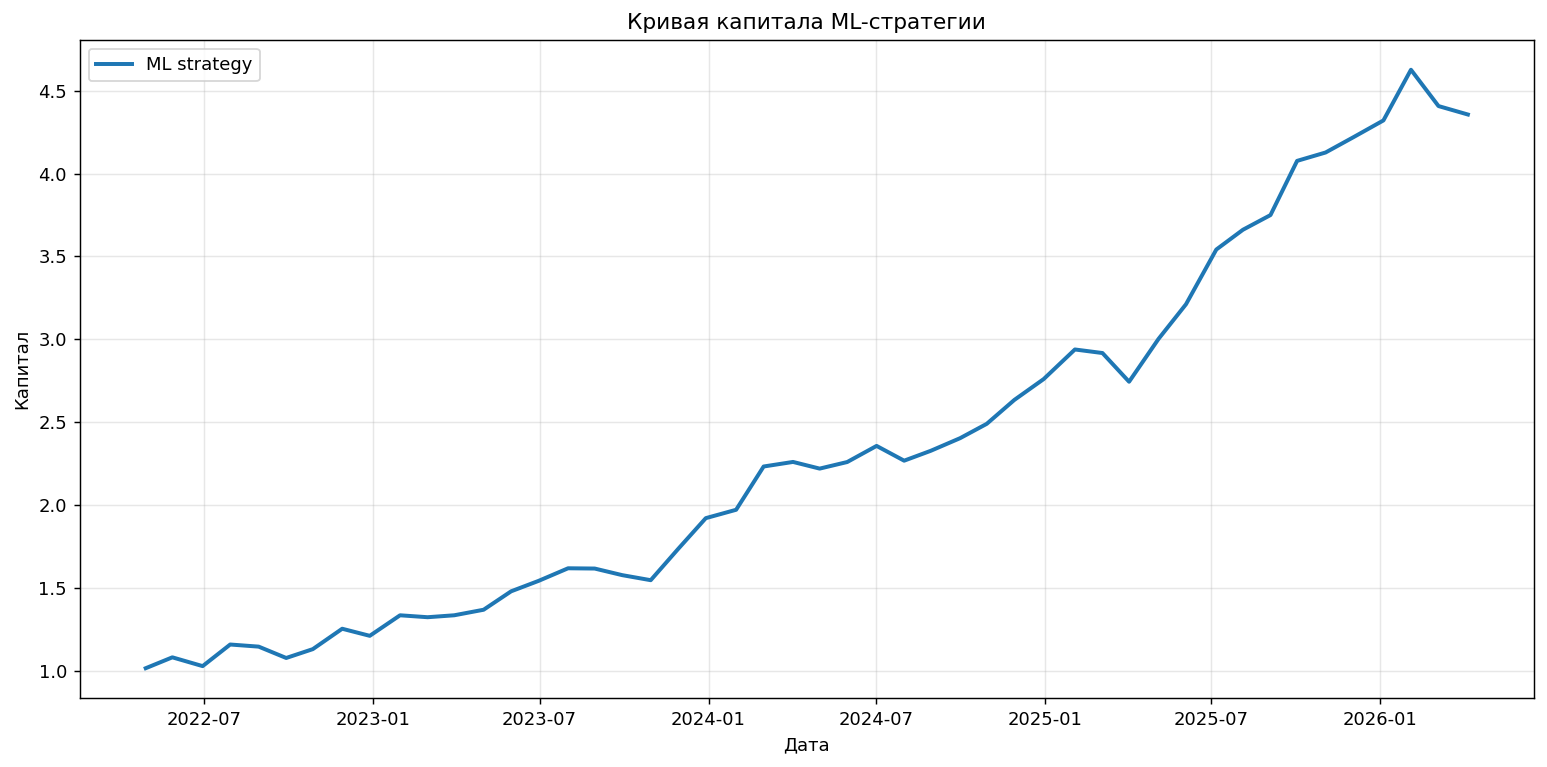

Saved figure: diploma_figures/02_strategy_vs_buy_hold.png


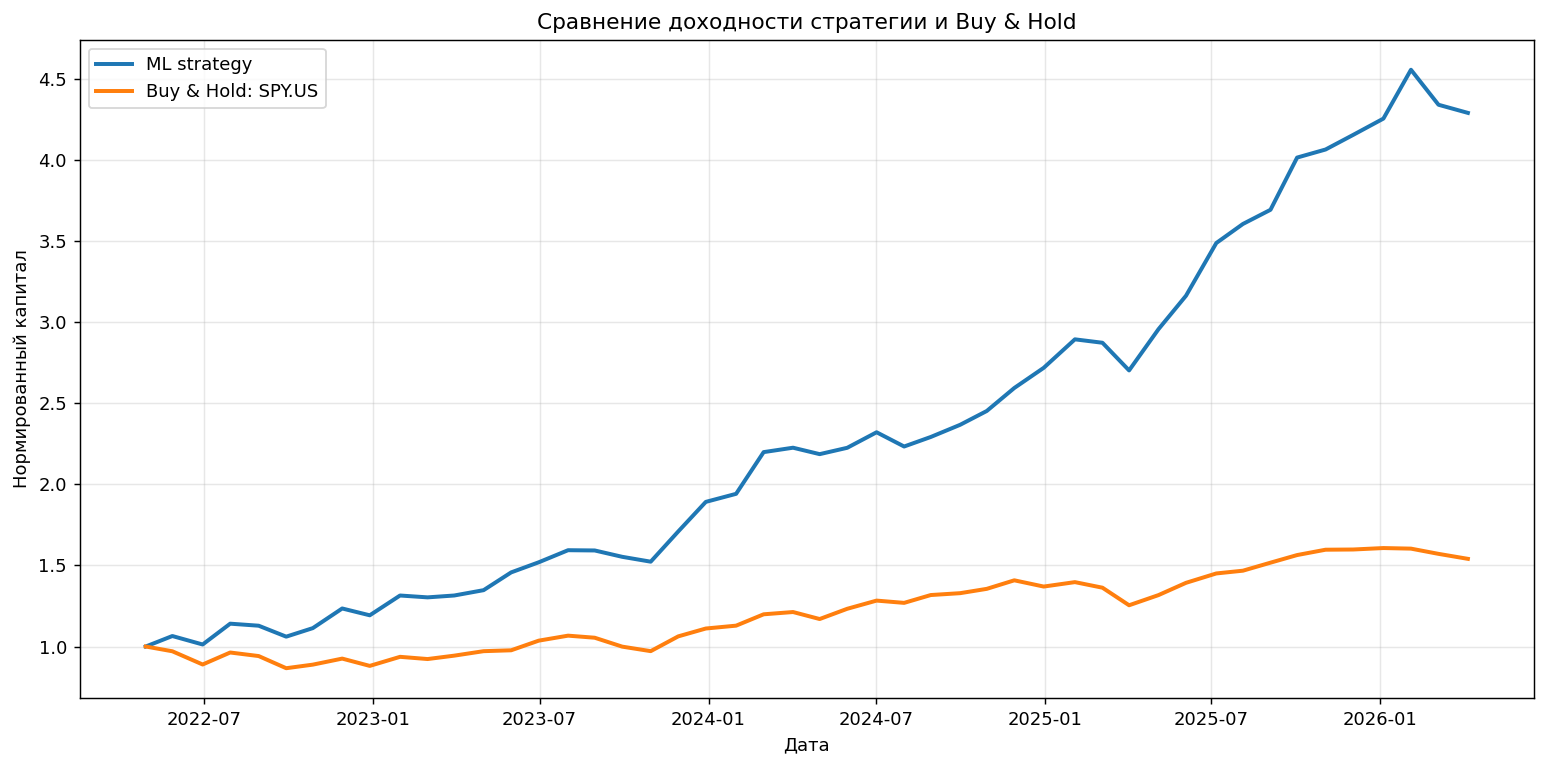

Saved figure: diploma_figures/03_drawdown_comparison.png


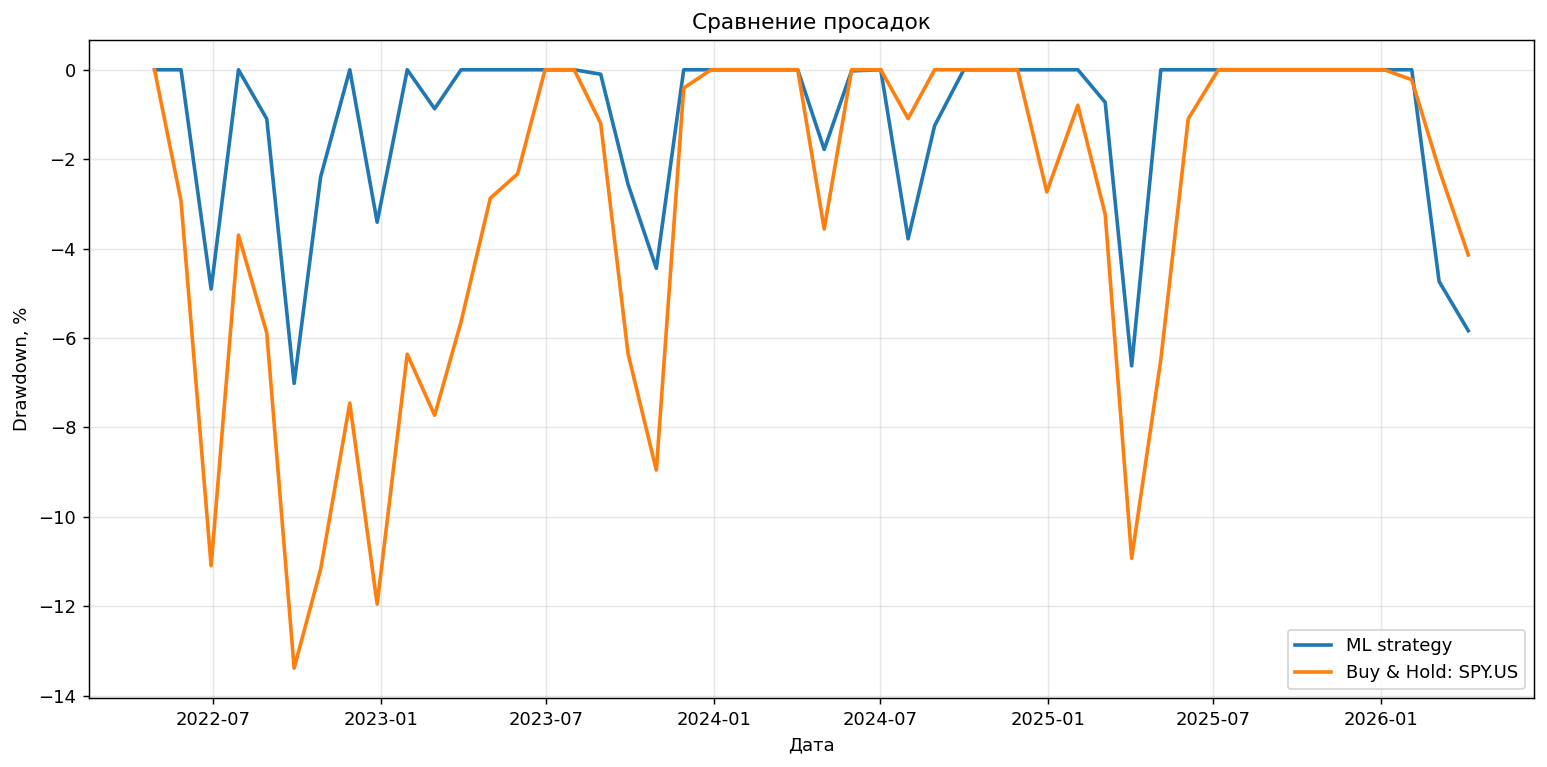

Saved figure: diploma_figures/04_turnover.png


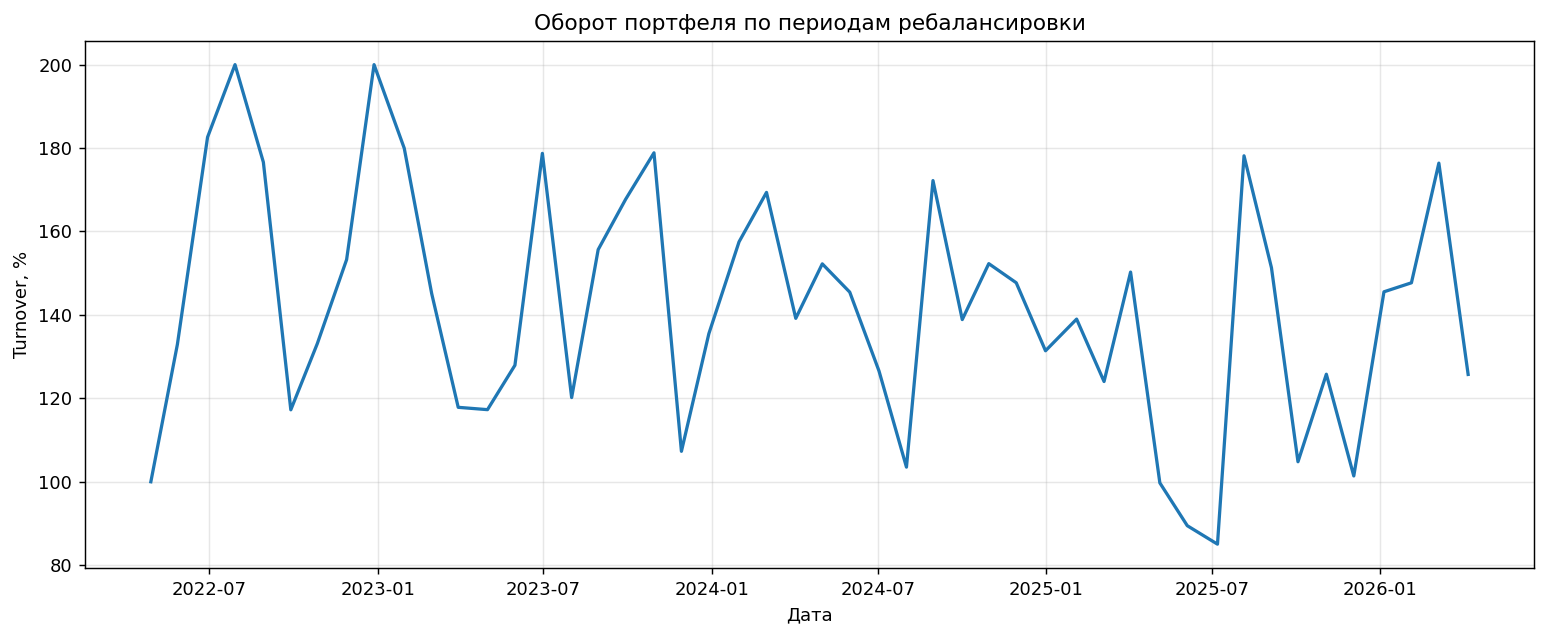

Saved figure: diploma_figures/05_return_distribution.png


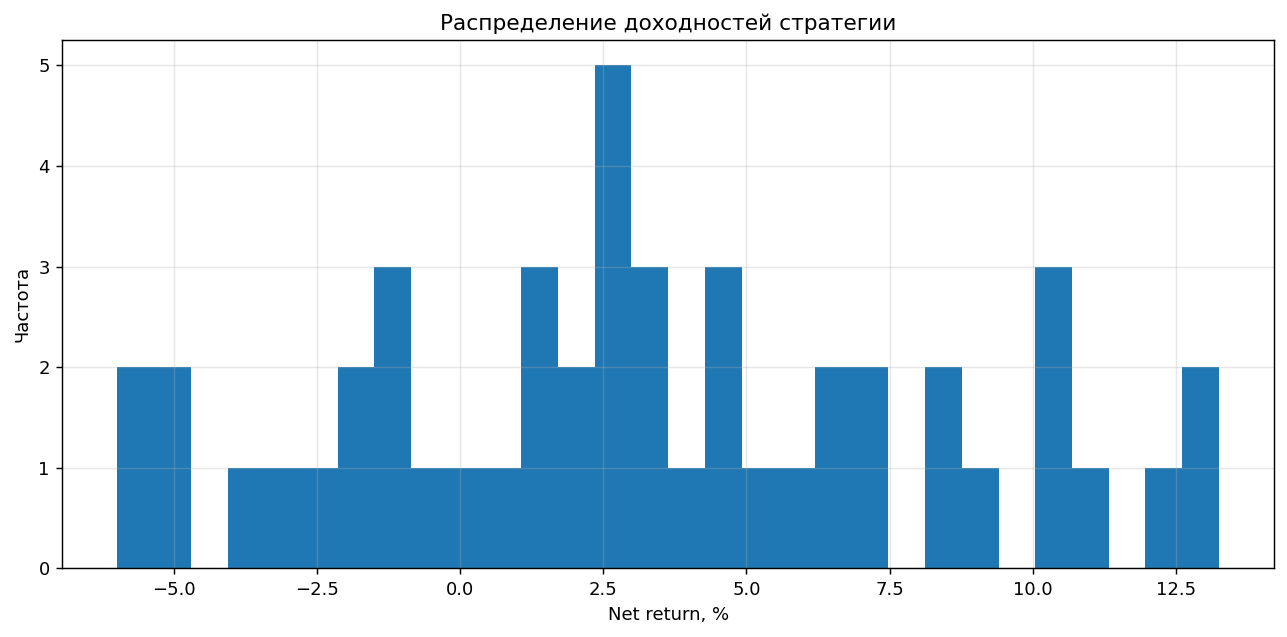

Saved figure: diploma_figures/06_prediction_vs_target_scatter.png


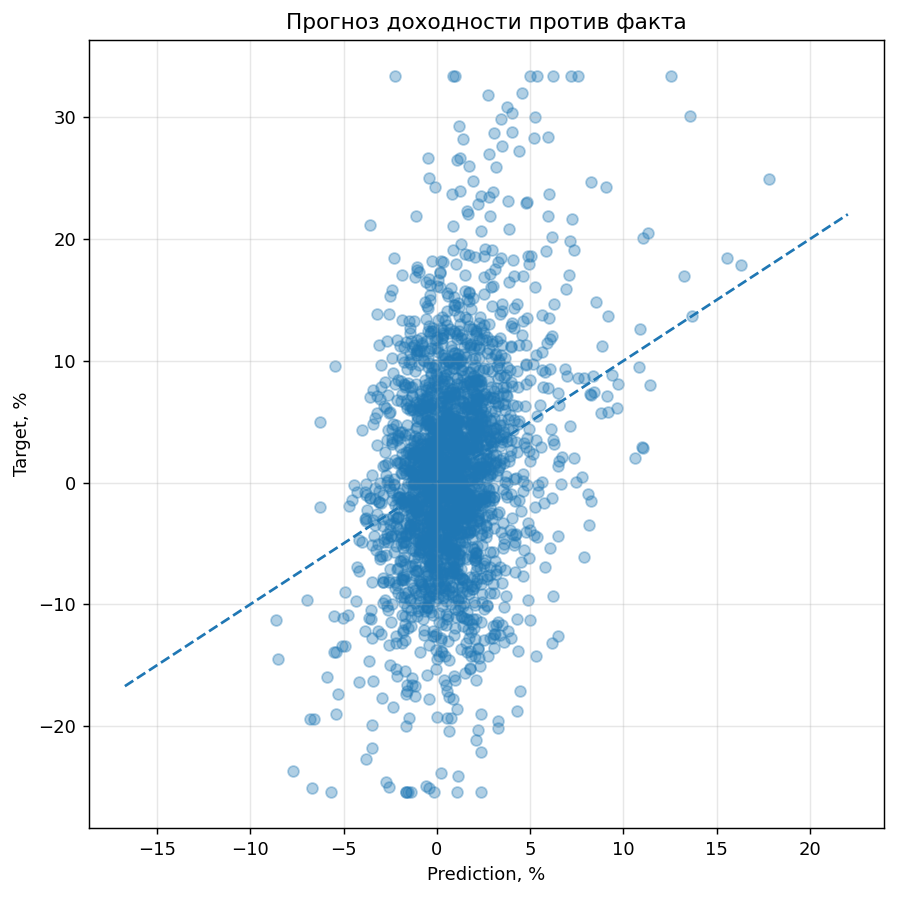

Saved figure: diploma_figures/07_information_coefficient.png


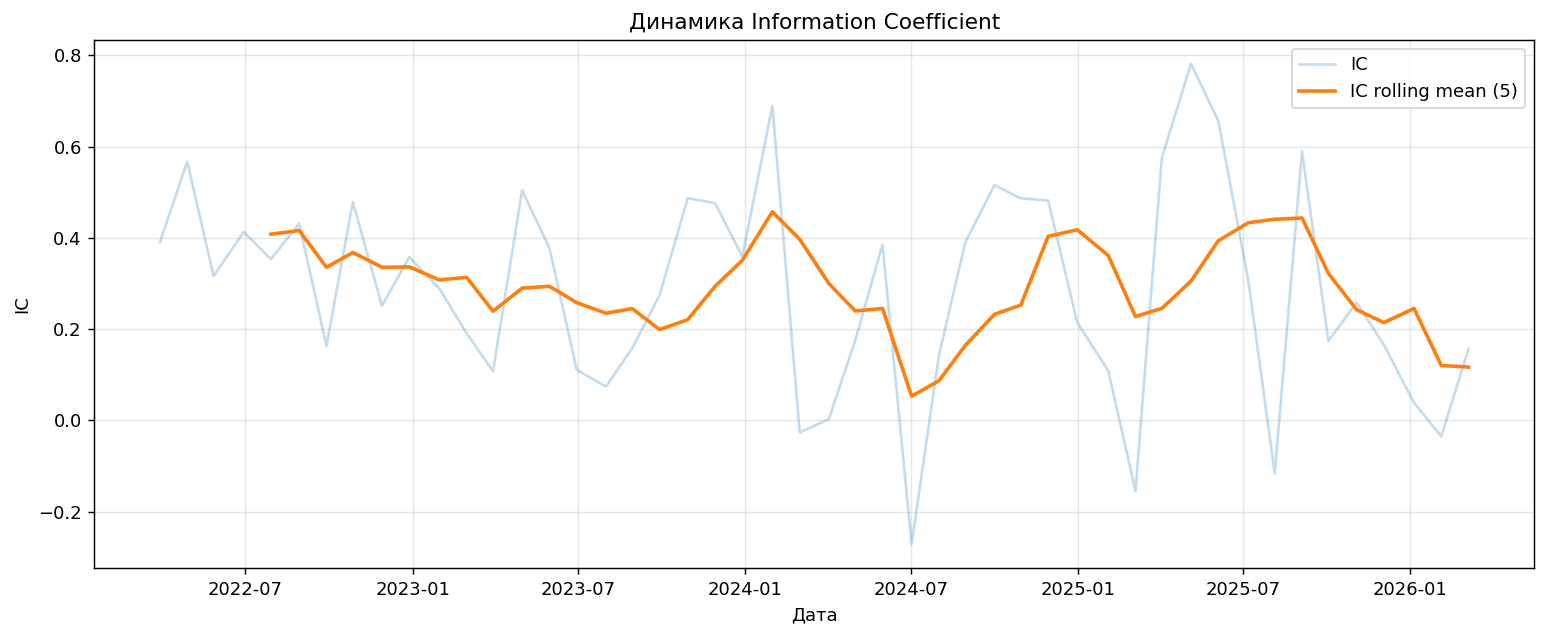

Saved figure: diploma_figures/08_mean_prediction_vs_target_by_fold.png


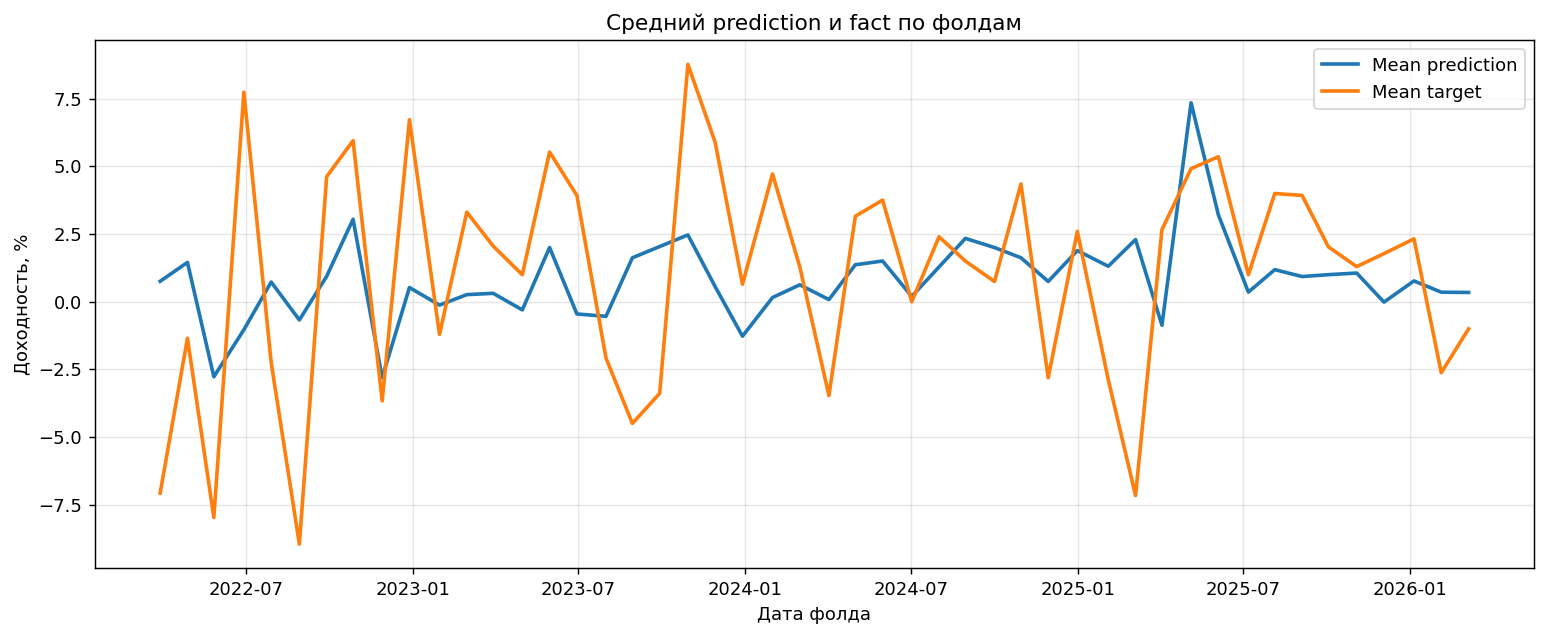

Saved figure: diploma_figures/09_top10_prediction_vs_target_by_fold.png


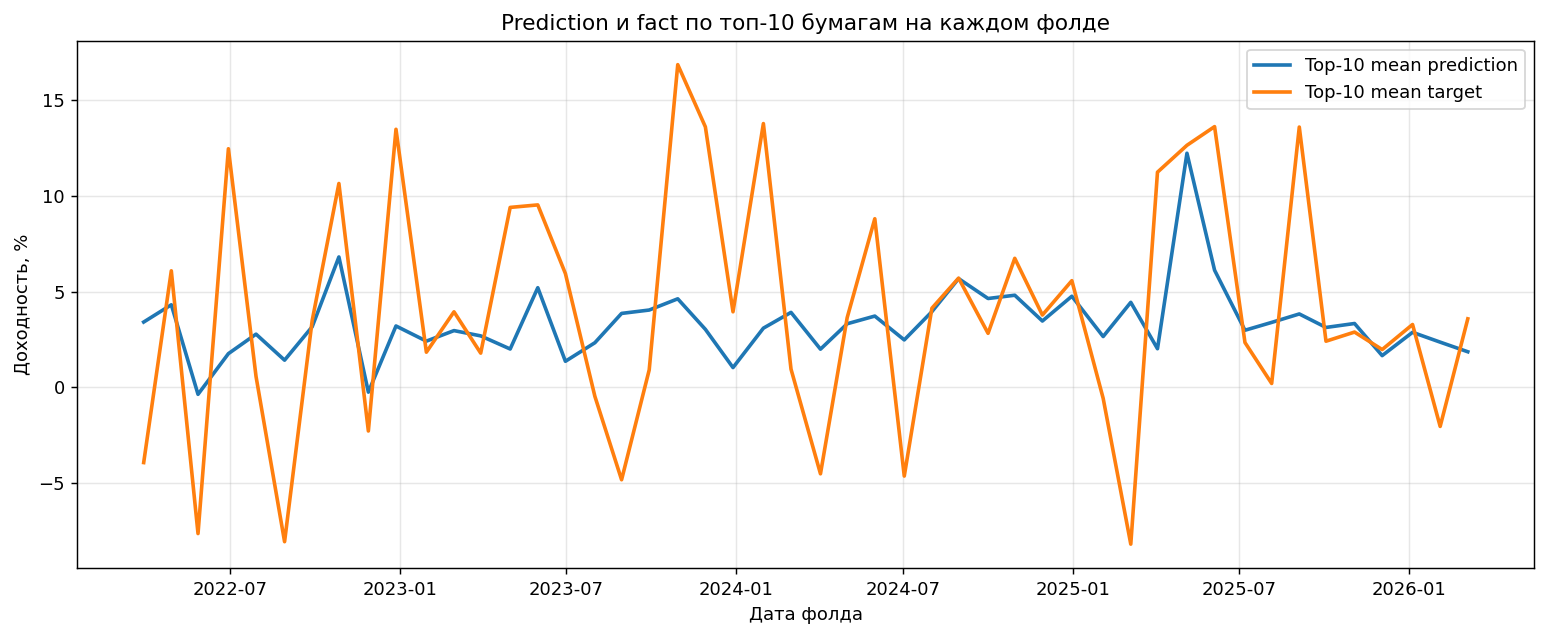

Saved figure: diploma_figures/10_error_metrics_by_fold.png


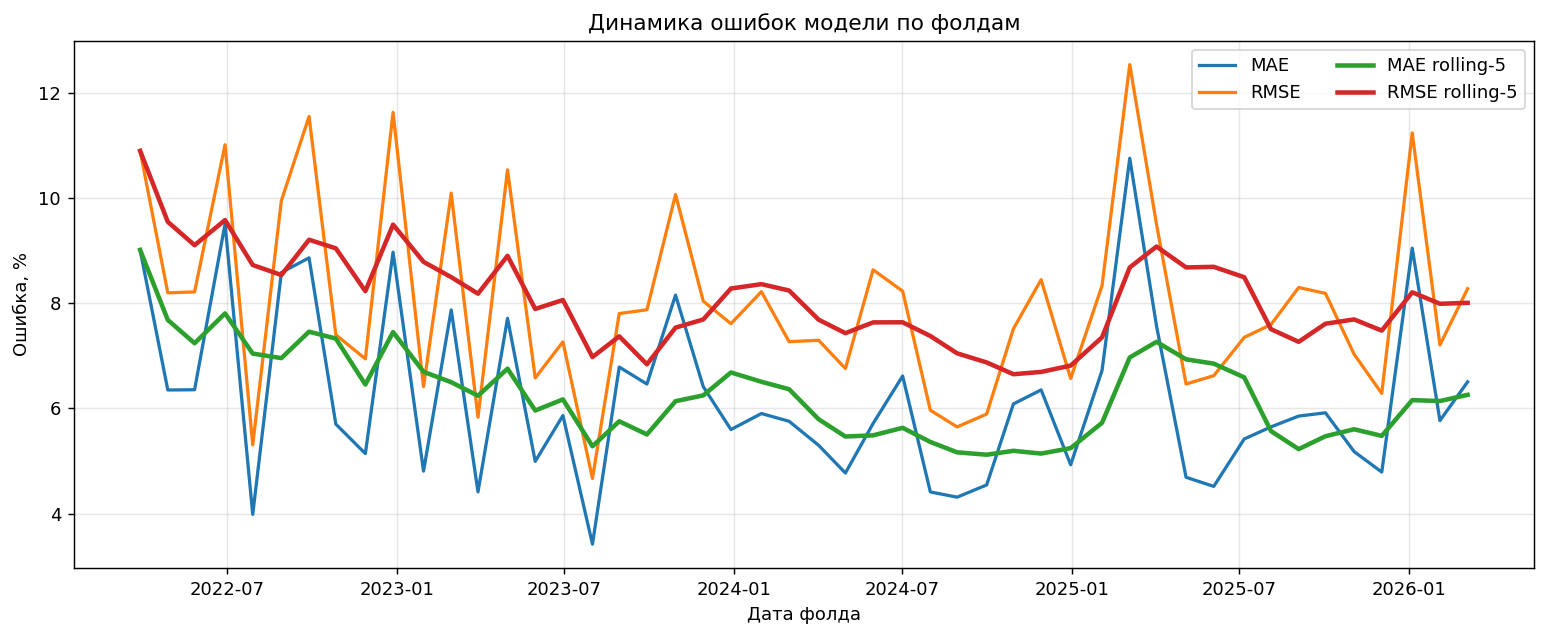

Saved figure: diploma_figures/11_directional_accuracy_by_fold.png


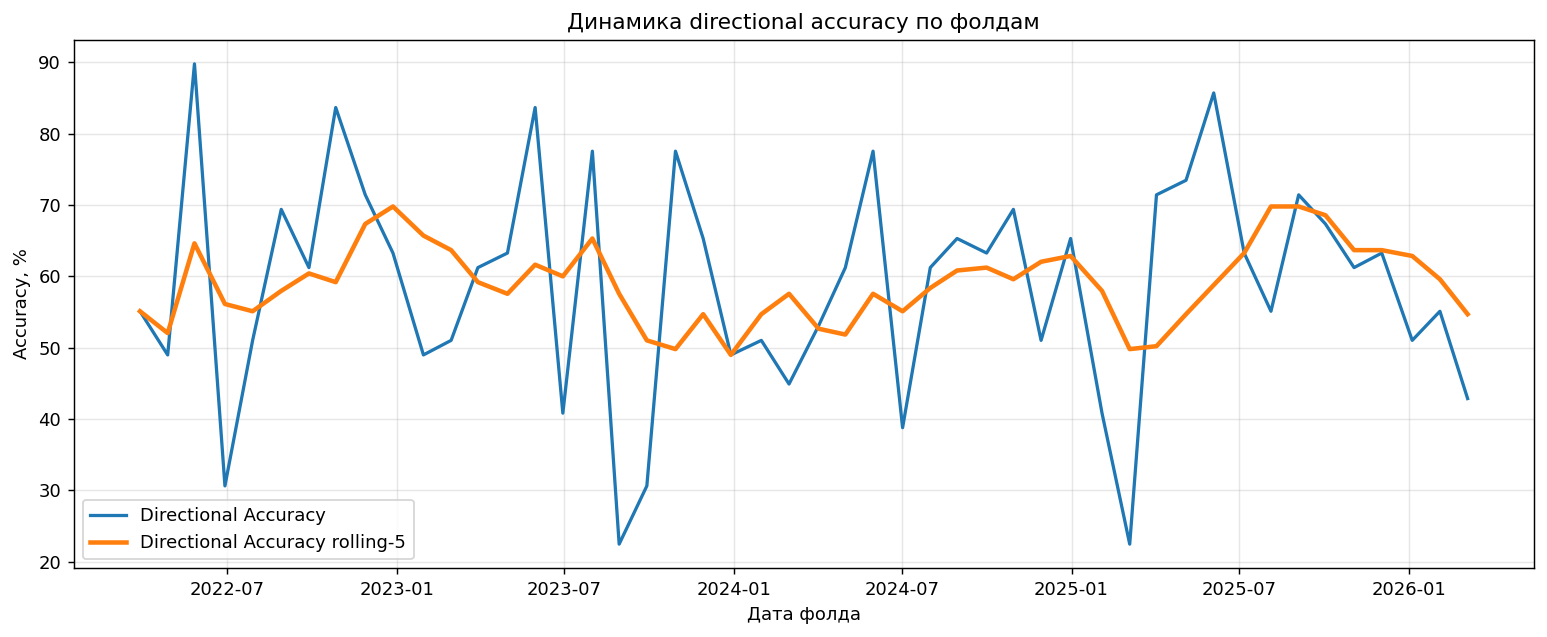

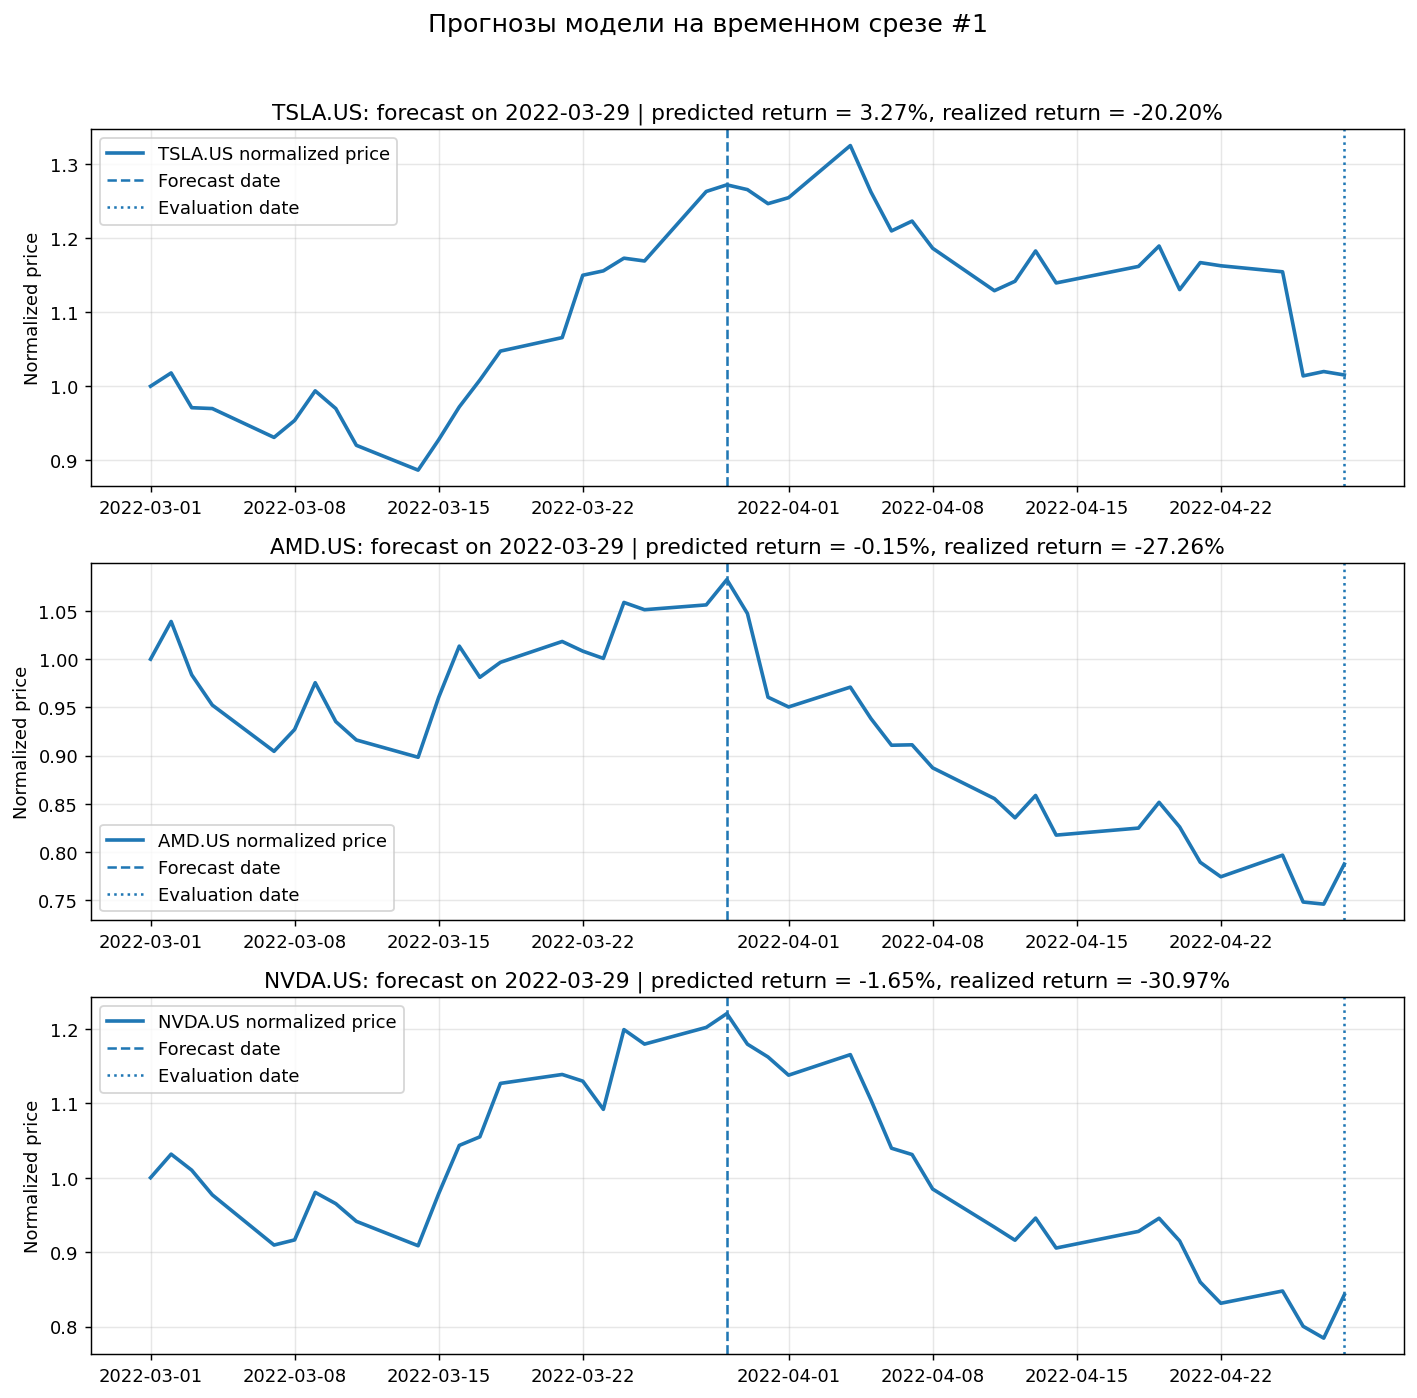

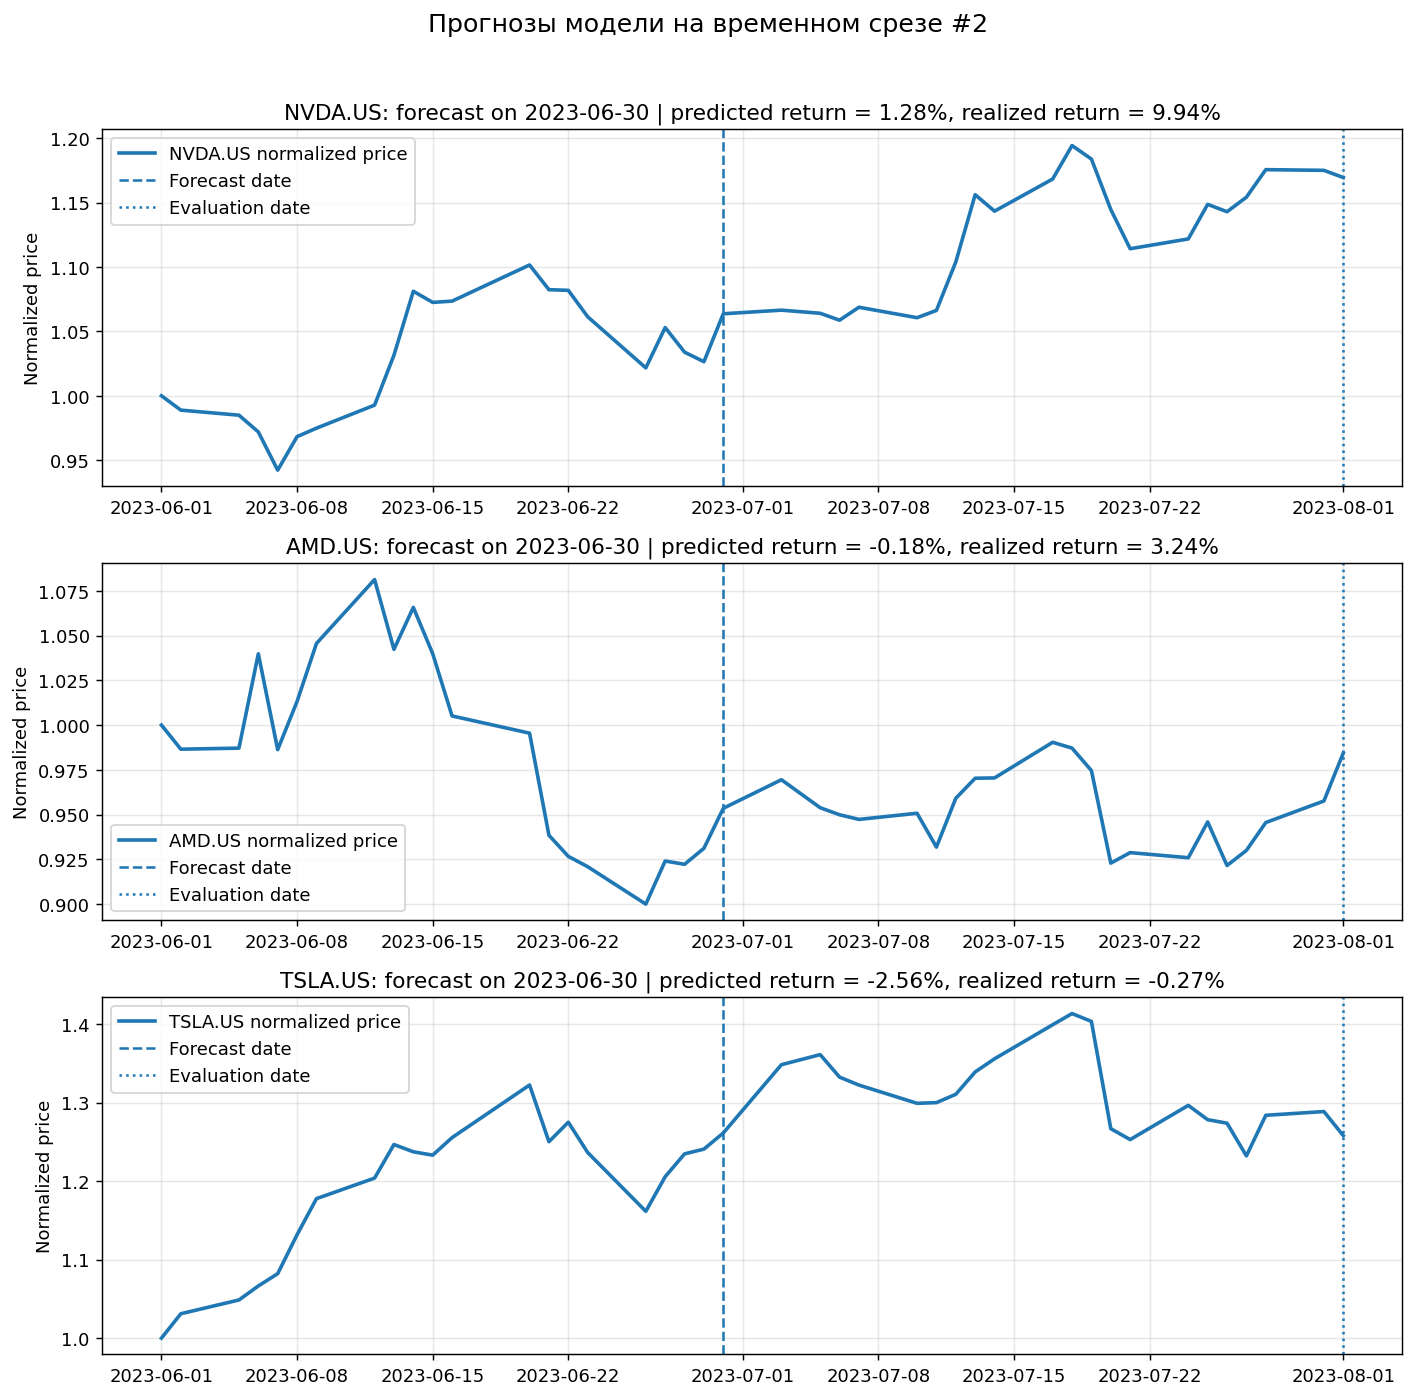

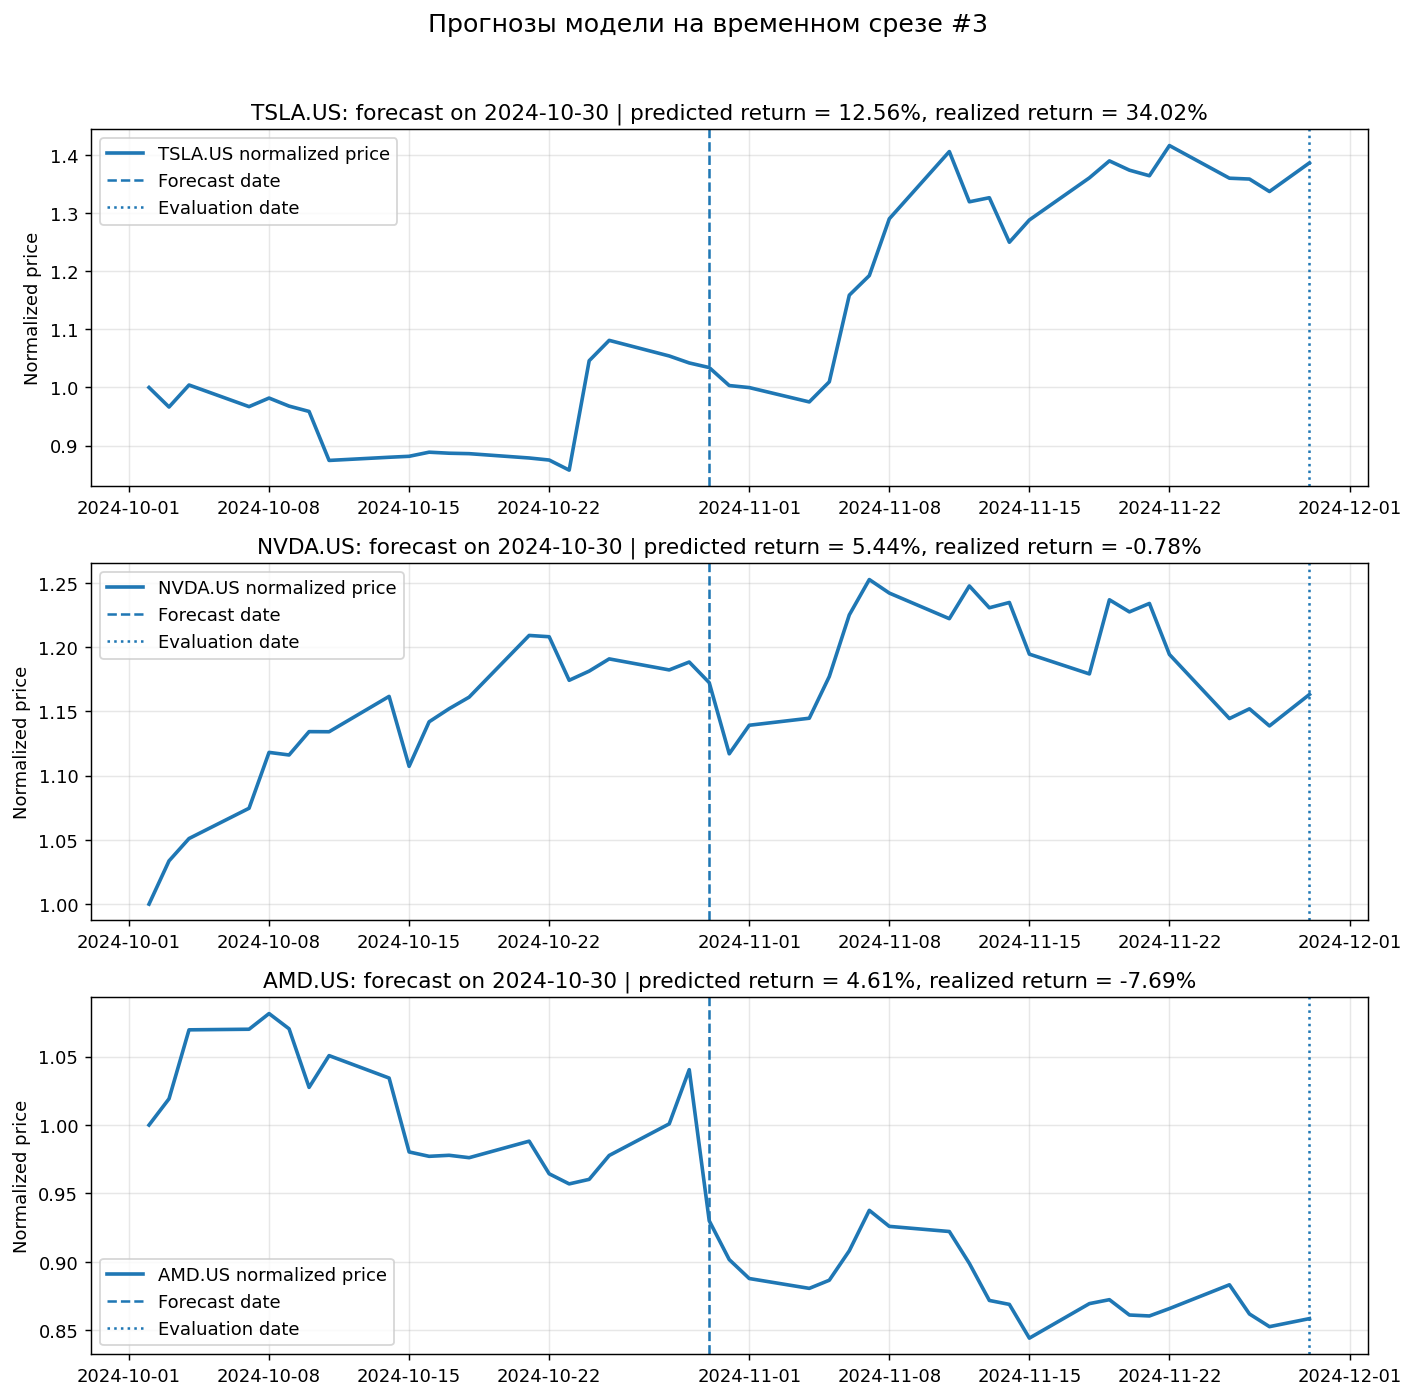

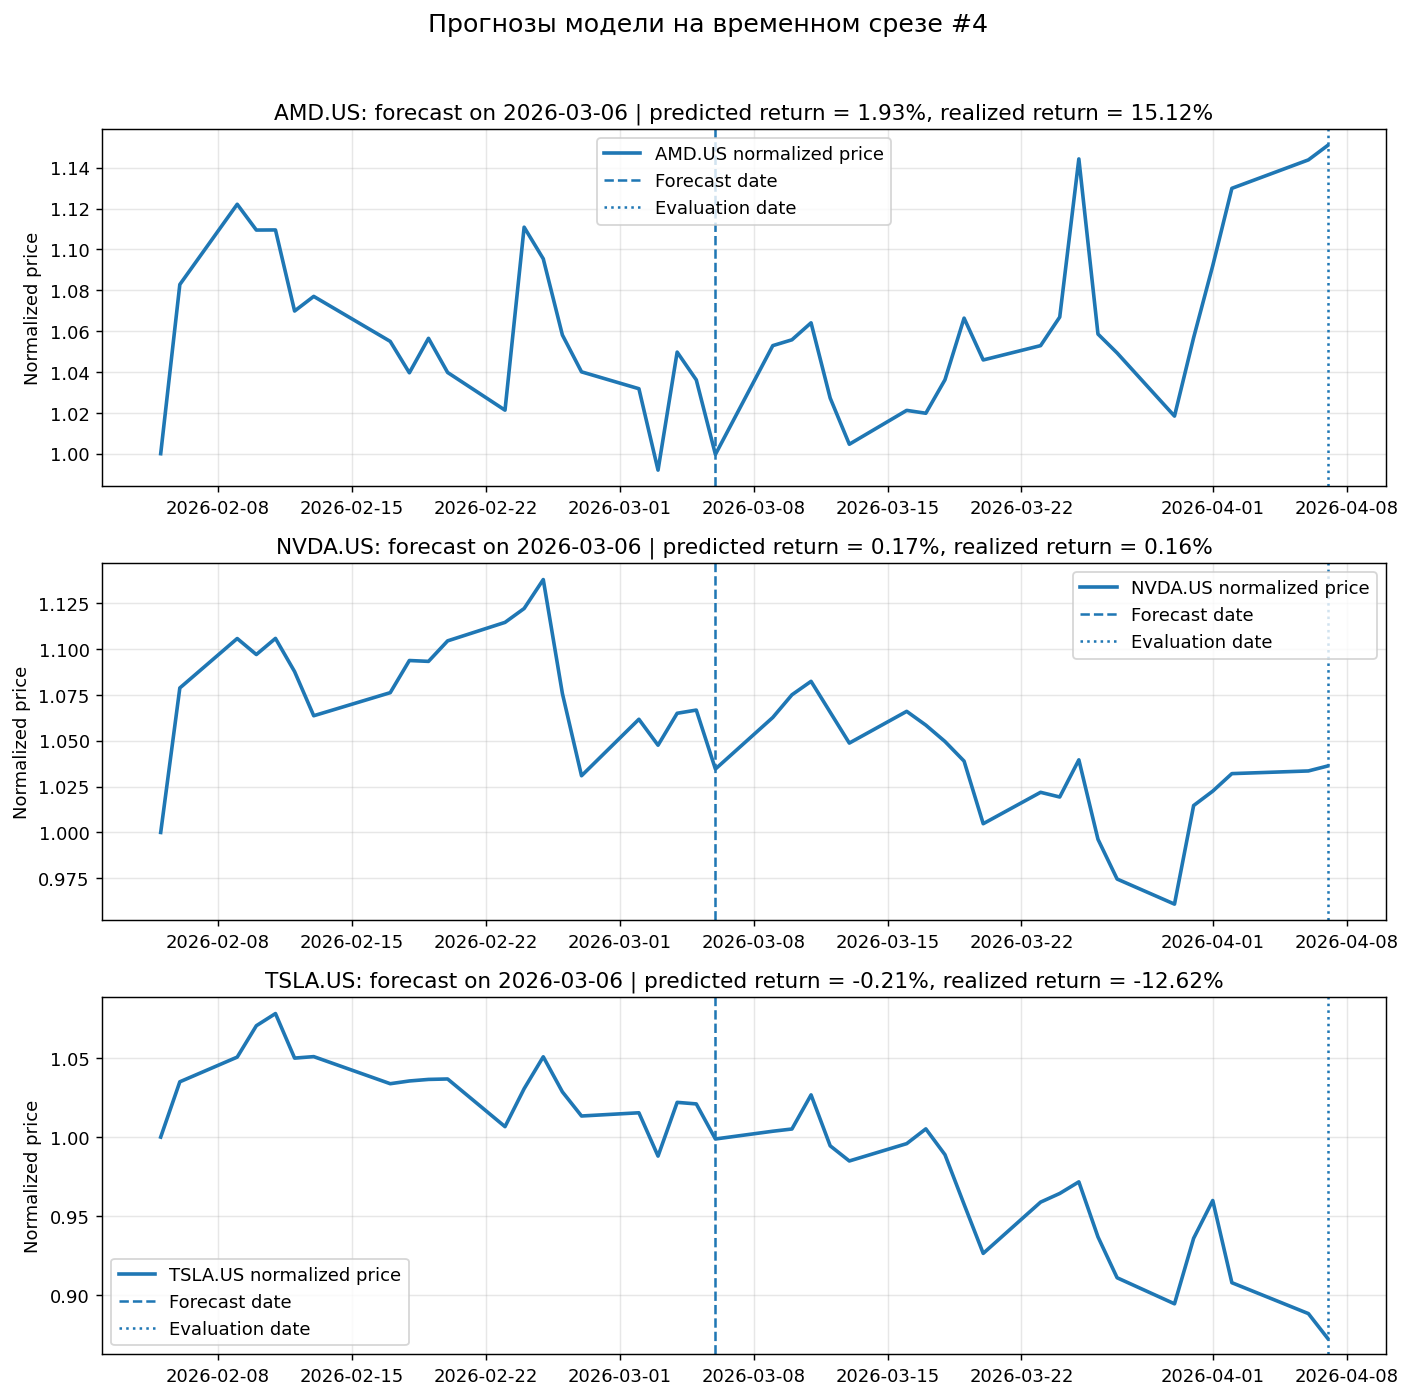

Saved figure: diploma_figures/12_portfolio_prediction_vs_fact_by_fold.png


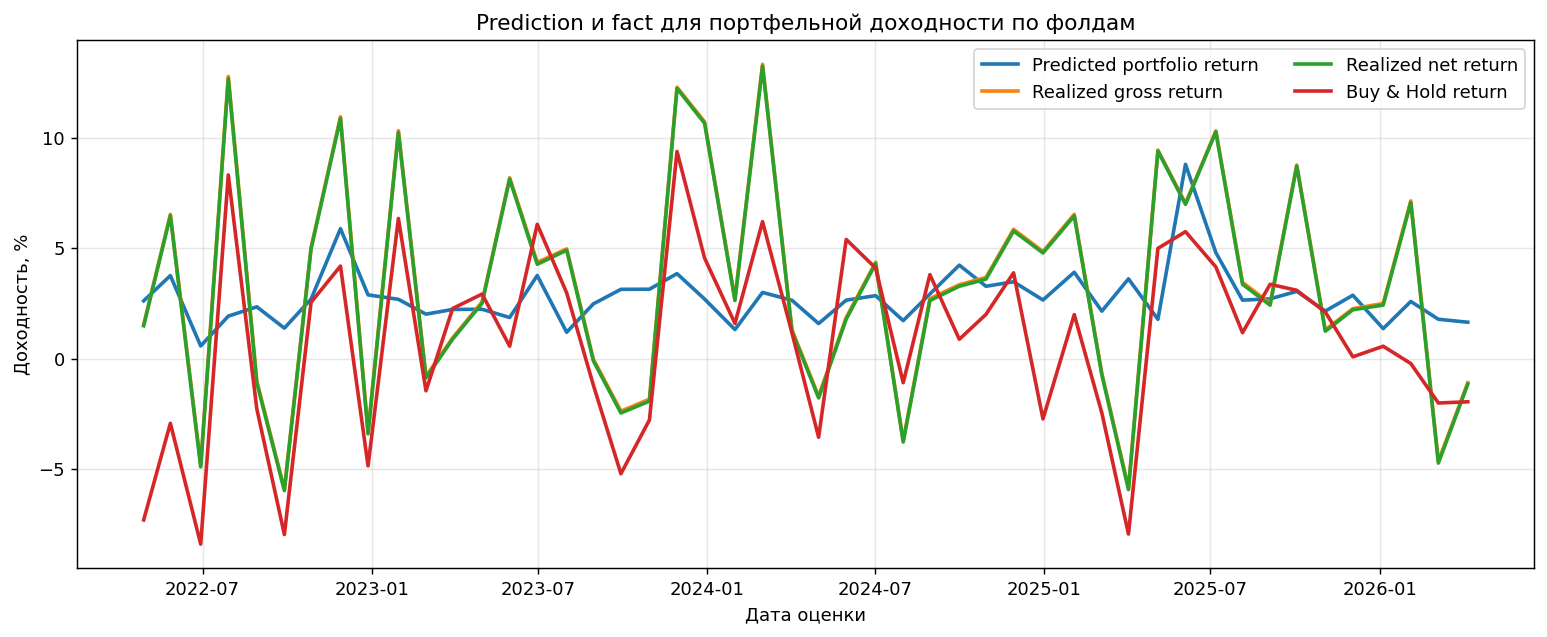

Saved figure: diploma_figures/13_feature_importance.png


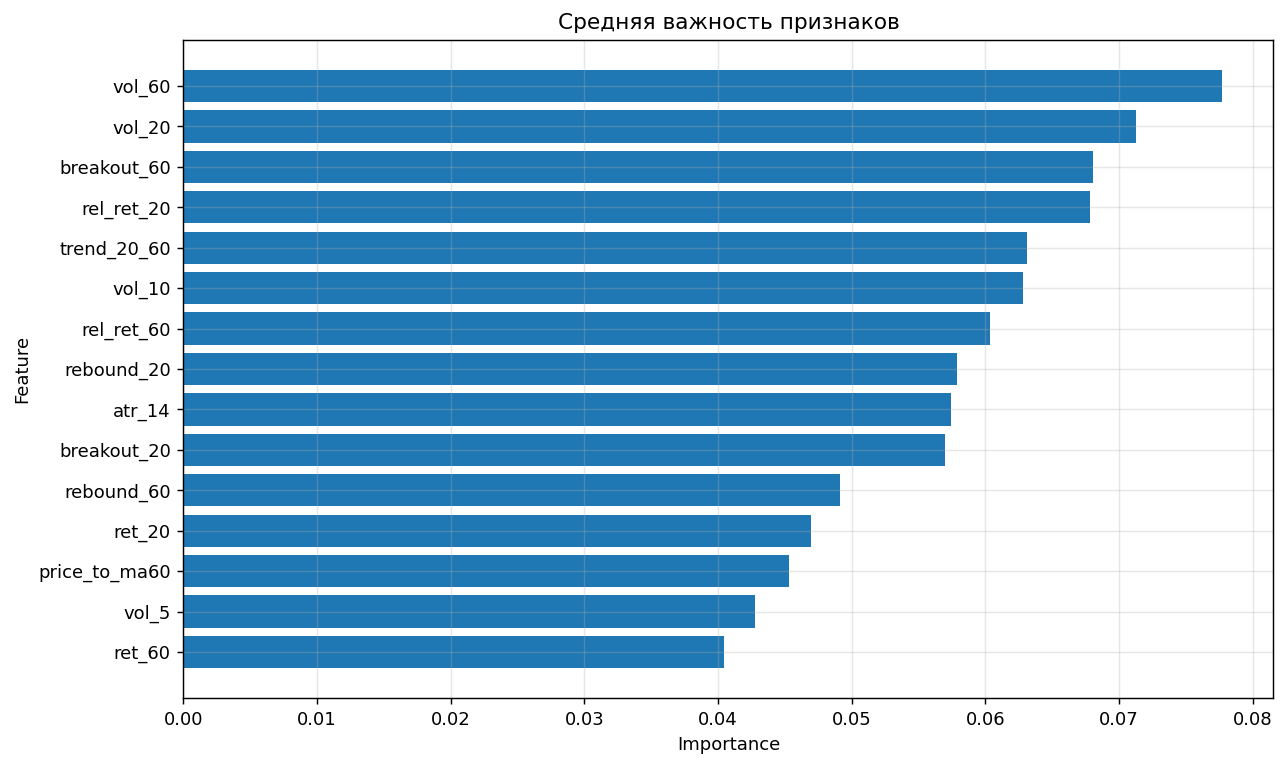

In [16]:
SHOW_PROGRESS = True
HORIZON = 21
USE_VOLUME_FEATURES = True
OBJECTIVE = "max_sharpe"
TRAIN_WINDOW = 504
RETRAIN_FREQ = 21
REBALANCE_FREQ = 21
TRANSACTION_COST = 0.0005
MAX_WEIGHT = 0.12
VERBOSE_EVERY = 50
BENCHMARK_TICKER = "SPY.US"

pipeline_output = run_ml_portfolio_pipeline(
    df_all=df_all,
    horizon=HORIZON,
    use_volume_features=USE_VOLUME_FEATURES,
    objective=OBJECTIVE,
    train_window=TRAIN_WINDOW,
    retrain_freq=RETRAIN_FREQ,
    rebalance_freq=REBALANCE_FREQ,
    max_weight=MAX_WEIGHT,
    transaction_cost=TRANSACTION_COST,
    verbose_every=VERBOSE_EVERY,
    benchmark_ticker=BENCHMARK_TICKER,
    show_progress=SHOW_PROGRESS
)

(
    dataset_ml,
    feature_cols_ml,
    results_ml_df,
    preds_ml_df,
    fi_ml_df,
    ml_metrics,
    portfolio_metrics,
    buy_hold_metrics,
    metrics_table,
    ml_metrics_by_fold,
    strategy_metrics_by_fold
) = pipeline_output

### Сохранённые изображения
После выполнения ноутбука качественные графики для диплома автоматически сохраняются в папку `diploma_figures` в формате PNG (300 dpi).

## 15. Просмотр итоговых таблиц

Итоговые таблицы можно использовать для дальнейшего анализа: `results_ml_df` содержит динамику портфеля, `preds_ml_df` — прогнозы модели и фактические доходности, `fi_ml_df` — важности признаков при переобучении модели.

In [17]:
display(results_ml_df.head())
display(preds_ml_df.head())
display(fi_ml_df.head())
display(metrics_table)
display(ml_metrics_by_fold.head(10))
display(strategy_metrics_by_fold.head(10))

,dt,next_dt,period_days,predicted_portfolio_return,gross_return,turnover,cost,net_return,n_assets,equity_curve,cummax_equity,drawdown
0,2022-03-29,2022-04-28,21,0.026175,0.015394,1.000000,0.000500,0.014894,12,1.014894,1.014894,0.000000
1,2022-04-28,2022-05-27,21,0.037617,0.065392,1.329211,0.000665,0.064728,12,1.080585,1.080585,0.000000
2,2022-05-27,2022-06-29,21,0.005724,-0.048162,1.826158,0.000913,-0.049075,3,1.027556,1.080585,-0.049075
3,2022-06-29,2022-07-29,21,0.019239,0.127868,2.000000,0.001000,0.126868,10,1.157920,1.157920,0.000000
4,2022-07-29,2022-08-29,21,0.023480,-0.010106,1.766158,0.000883,-0.010989,12,1.145195,1.157920,-0.010989


Price,dt,next_dt,ticker,close,prediction,target,realized_period_return,predicted_end_price,realized_end_price
0,2022-03-29,2022-04-28,AAPL.US,178.960007,0.013546,-0.085606,-0.085606,181.384196,163.639999
1,2022-03-29,2022-04-28,ABBV.US,162.179993,-0.009221,-0.036194,-0.036194,160.684490,156.309998
2,2022-03-29,2022-04-28,ADBE.US,466.329987,-0.015351,-0.119658,-0.119658,459.171405,410.529999
3,2022-03-29,2022-04-28,AMD.US,123.230003,-0.001535,-0.254455,-0.272580,123.040888,89.639999
4,2022-03-29,2022-04-28,AMZN.US,169.315002,0.006699,-0.145991,-0.145991,170.449321,144.596497


,feature,importance,retrain_dt
0,ret_1,0.002848,2022-03-29
1,ret_3,0.015535,2022-03-29
2,ret_5,0.019066,2022-03-29
3,ret_10,0.008028,2022-03-29
4,ret_20,0.014242,2022-03-29


,Metric,ML Forecast Quality,ML Portfolio Strategy,Buy & Hold
0,MSE,67.63,NaN,NaN
1,RMSE,8.22%,NaN,NaN
2,MAE,6.21%,NaN,NaN
3,R2,0.098,NaN,NaN
4,Directional Accuracy,58.80%,NaN,NaN
5,Prediction Corr,0.316,NaN,NaN
6,Mean IC,0.288,NaN,NaN
7,Median IC,0.298,NaN,NaN
8,Mean Return,NaN,3.24%,0.84%
9,Annualized Return,NaN,44.47%,9.32%


,dt,"MAE, %","RMSE, %","Directional Accuracy, %",IC,"Mean Prediction, %","Mean Target, %","Top-10 Mean Prediction, %","Top-10 Mean Target, %",Coverage,"MAE rolling-5, %","RMSE rolling-5, %","DA rolling-5, %",IC rolling-5
0,2022-03-29,9.012383,10.895896,55.102041,0.390577,0.746564,-7.075616,3.414484,-3.921641,49,9.012383,10.895896,55.102041,0.390577
1,2022-04-28,6.349892,8.196319,48.979592,0.567178,1.445314,-1.356436,4.316420,6.087837,49,7.681138,9.546107,52.040816,0.478878
2,2022-05-27,6.354496,8.214395,89.795918,0.316454,-2.780339,-7.979540,-0.357796,-7.626568,49,7.238924,9.102203,64.625850,0.424736
3,2022-06-29,9.506231,11.011961,30.612245,0.413251,-1.043437,7.732401,1.765616,12.460442,49,7.805751,9.579643,56.122449,0.421865
4,2022-07-29,3.985015,5.306629,51.020408,0.353512,0.719480,-2.249926,2.782893,0.574656,49,7.041604,8.725040,55.102041,0.408194
5,2022-08-29,8.582571,9.947073,69.387755,0.431600,-0.682268,-8.964850,1.424399,-8.052448,49,6.955641,8.535275,57.959184,0.416399
6,2022-09-28,8.861911,11.548693,61.224490,0.163330,0.932259,4.613828,3.170773,3.498821,49,7.458045,9.205750,60.408163,0.335629
7,2022-10-27,5.700962,7.399064,83.673469,0.478376,3.039383,5.943865,6.812103,10.648427,49,7.327338,9.042684,59.183673,0.368014
8,2022-11-28,5.140486,6.941616,71.428571,0.251358,-2.812819,-3.673436,-0.245237,-2.272200,49,6.454189,8.228615,67.346939,0.335635
9,2022-12-28,8.968223,11.627616,63.265306,0.358074,0.516558,6.715962,3.208916,13.476208,49,7.450830,9.492812,69.795918,0.336548


,dt,next_dt,"Predicted Portfolio Return, %","Gross Return, %","Net Return, %","Turnover, %","Transaction Cost, %",equity_curve,"Drawdown, %",n_assets,"Rolling 5-fold Net Return, %","Rolling 5-fold Volatility, %","Buy & Hold Return, %",Buy & Hold Equity,"Excess Return vs Buy & Hold, %"
0,2022-03-29,2022-04-28,2.617502,1.539368,1.489368,100.000000,0.050000,1.014894,0.000000,12,1.489368,NaN,-7.310149,0.926899,8.799516
1,2022-04-28,2022-05-27,3.761724,6.539221,6.472760,132.921060,0.066461,1.080585,0.000000,12,8.058531,3.523791,-2.933542,0.899708,9.406303
2,2022-05-27,2022-06-29,0.572365,-4.816161,-4.907469,182.615816,0.091308,1.027556,-4.907469,3,2.755592,5.704725,-8.409192,0.824049,3.501723
3,2022-06-29,2022-07-29,1.923876,12.786818,12.686818,200.000000,0.100000,1.157920,0.000000,10,15.792007,7.465586,8.321500,0.892623,4.365318
4,2022-07-29,2022-08-29,2.348002,-1.010616,-1.098923,176.615802,0.088308,1.145195,-1.098923,12,14.519542,6.846171,-2.271896,0.872343,1.172973
5,2022-08-29,2022-09-28,1.380669,-5.924886,-5.983512,117.253315,0.058627,1.076673,-7.016681,12,6.087222,7.963423,-7.972582,0.802795,1.989070
6,2022-09-28,2022-10-27,2.697156,5.030726,4.964156,133.138860,0.066569,1.130120,-2.400844,12,4.584081,7.750516,2.550404,0.823269,2.413752
7,2022-10-27,2022-11-28,5.888540,10.959631,10.883000,153.261304,0.076631,1.253111,0.000000,12,21.950657,7.890093,4.192324,0.857784,6.690676
8,2022-11-28,2022-12-28,2.887928,-3.311598,-3.411598,200.000000,0.100000,1.210360,-3.411598,2,4.528811,6.819098,-4.862216,0.816076,1.450618
9,2022-12-28,2023-01-30,2.685852,10.330315,10.240338,179.954395,0.089977,1.334305,0.000000,12,16.513306,7.740500,6.353208,0.867923,3.887130
